PREGUNTAS A RESPONDER:
-CUALES SON LAS VARIABLES QUE DETERMINAN QUE UN EQUIPO SEA MEJOR QUE OTRO EN UNA TEMPORADA?
-Clustering: Agrupar equipos según su eficiencia (goles/tiros, goles/posesión, etc.) para ver qué grupos de equipos son más efectivos.(Identificacion patrones de eficacia). Podriamos resolver valores atipicos en base a comapraciones finales
-Clustering: Equipos con estilos similares (segun variables)
-Clustering ¿Qué jugadores o equipos generan más acciones clave (pases, tiros, recuperaciones) en los partidos? - jugadores mas influyentes segun registros, que equipos dependen de mas acciones individuales
-Partidos mas taquilleros (se puede??)
-¿Qué equipos recibieron más presión en campo rival?
-¿En qué minutos se concentran más goles en la liga/torneo?
-EXPLORATORIO/OUTLIERS: ¿Qué jugadores generan valores atípicos en volumen de acciones clave (ej. un mediocampista con más recuperaciones que el promedio de su liga)?

-PREDECIR EQUIPO CAMPEON 2025/2026

UNION DE DATASET: COMPETITIONS + MATCHES + EVENTS (ANALISIS MÁS CLASICO)
UNION DE DATASET: COMPETITIONS + MATCHES + EVENTS (MÁS GRANULAR (ANALISIS ESPACIAL Y DINAMICO (TRACKING)))

In [1]:
#libraries
#pip install statsbombpy - libreria de Hudl
#pip install mplsoccer - traza de canchas, graficos (radar, pizza, cambios en el tiempo, etc), flechas, mapas de calor, entre otros.
#URL MPLSOCCER DOCS: https://mplsoccer.readthedocs.io/en/latest/
#pakcs
from statsbombpy import sb
import pandas as pd
from mplsoccer import VerticalPitch,Pitch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
import numpy as np
from IPython.display import display
from sklearn.metrics import mean_squared_error
#escalado de datos
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
#clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
#regresion lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
#regresion logistica
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
#SVM
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
#Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

ETAPA DE PREPARACIÓN DE DATOS: Como sabemos que tenemos un grupo de datos muy amplio, de diferentes grupos (competencias, paises, generos) lo primero que se realizo fue filtrar la cantidad de temporadas disponibles por campeonato, y de esta manera usar aquella liga o torneo que nos proporcione datos en masa y de calidad. Asi logramos conocer que disponemos de 17 temporadas de la liga masculina del futbol español (La Liga).

In [2]:
#LaLiga => competition_id=11; TENEMOS 17 TEMPORADAS
#VARIABLES A DEJAR: competition_id; season_id; competition_name; season_name
#seasons = [[37,38,39,40,41,21,22,23,24,25,26,27,2,1,4,42,90]] - seasons_id
competitions = sb.competitions();
la_liga = competitions[competitions["competition_id"]==11];
la_liga.head(17)

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
38,11,90,Spain,La Liga,male,False,False,2020/2021,2025-01-29T17:39:28.924386,2025-01-29T18:09:18.620699,2025-01-29T18:09:18.620699,2025-01-29T17:39:28.924386
39,11,42,Spain,La Liga,male,False,False,2019/2020,2024-12-16T16:51:06.833054,2021-06-13T16:17:31.694,None,2024-12-16T16:51:06.833054
40,11,4,Spain,La Liga,male,False,False,2018/2019,2024-09-22T18:50:23.364757,2021-07-09T14:53:22.103024,None,2024-09-22T18:50:23.364757
41,11,1,Spain,La Liga,male,False,False,2017/2018,2025-07-14T10:01:16.674864,2021-06-13T16:17:31.694,None,2025-07-14T10:01:16.674864
42,11,2,Spain,La Liga,male,False,False,2016/2017,2025-03-09T16:03:54.962718,2021-06-13T16:17:31.694,None,2025-03-09T16:03:54.962718
43,11,27,Spain,La Liga,male,False,False,2015/2016,2025-04-23T13:59:22.835792,2021-06-13T16:17:31.694,None,2025-04-23T13:59:22.835792
44,11,26,Spain,La Liga,male,False,False,2014/2015,2025-06-24T13:39:01.068680,2021-06-13T16:17:31.694,None,2025-06-24T13:39:01.068680
45,11,25,Spain,La Liga,male,False,False,2013/2014,2025-06-24T09:52:44.048585,2021-06-13T16:17:31.694,None,2025-06-24T09:52:44.048585
46,11,24,Spain,La Liga,male,False,False,2012/2013,2025-06-24T13:53:14.047130,2021-06-13T16:17:31.694,None,2025-06-24T13:53:14.047130
47,11,23,Spain,La Liga,male,False,False,2011/2012,2025-06-24T13:38:10.764259,2021-06-13T16:17:31.694,None,2025-06-24T13:38:10.764259


ANÁLISIS GRÁFICO Y DESCRIPTIVO: No solo nos quedamos con la eleccion de las temporadas, y tampoco lo hicimos "porque si"; a continuacion se logra observar un grafico de dispersion donde se ve un conjunto de valores mayor y menos disperso desde el año 2004 a 2021

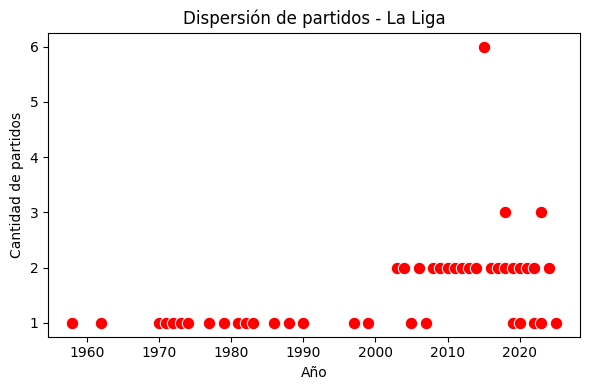

In [3]:
#cuenteo de partidos por temp
partidos_x_temp = competitions.groupby('season_name').size().reset_index(name='cantidad_partidos')
#Prueba grafica (x,y) donde se visualicen cant de partidos por año
partidos_x_temp['season_year'] = partidos_x_temp['season_name'].str[:4].astype(int)

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='season_year', 
    y='cantidad_partidos', 
    data=partidos_x_temp,
    s=80, color='red'
)
plt.xlabel('Año')
plt.ylabel('Cantidad de partidos')
plt.title('Dispersión de partidos - La Liga')
plt.tight_layout()
plt.show()


In [4]:
#variables - matches
#DEJAR EN EL DATASET: match_date; home_team; away_team;home_score; away_score; match_week; competition_stage; stadium; home_managers; away_managers
matches = sb.matches(competition_id=11,season_id=90);
matches.head(1)

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3773386,2020-10-31,21:00:00.000,Spain - La Liga,2020/2021,Deportivo Alavés,Barcelona,1,1,available,...,2023-07-25T04:25:41.348202,8,Regular Season,Estadio de Mendizorroza,NaN,Pablo Javier Machín Díez,Ronald Koeman,1.1.0,2,2


Conociendo la ubicacion cronologica de la mayoria de los datos a trabajar, se comenzo el proceso de unificacion de tablas para asi hacer más valiosos y brindarle significado a cada uno de los datos. Como primer unificacion se junto la tabla de las 17 temporadas (competitions) con cada uno de sus partidos.

In [5]:
#merge de competitions + matches (mediante competition_id y season_id)
competition_id = 11
seasons = [37,38,39,40,41,21,22,23,24,25,26,27,2,1,4,42,90]

competitions_reduce = sb.competitions()[['competition_id','season_id',
                                'competition_name','season_name','country_name']].drop_duplicates()

all_matches = []
for sid in seasons:
    m = sb.matches(competition_id=competition_id, season_id=sid)
    m['competition_id'] = 11
    m['season_id'] = sid

    m = m[['match_id','competition_id','season_id','match_date',
           'home_team','away_team','home_score','away_score',
           'match_week','competition_stage','stadium',
           'home_managers','away_managers']].copy()
    all_matches.append(m)

matches_df = pd.concat(all_matches, ignore_index=True)
# Ordenar por fecha descendente
matches_df = matches_df.sort_values('match_date', ascending=False).reset_index(drop=True)
# #sid == season_id
# #m == matches

merged = matches_df.merge(competitions_reduce, on=['competition_id','season_id'], how='left')

print(merged.shape)
merged


(867, 16)


,match_id,competition_id,season_id,match_date,home_team,away_team,home_score,away_score,match_week,competition_stage,stadium,home_managers,away_managers,competition_name,season_name,country_name
0,3773457,11,90,2021-05-16,Barcelona,Celta Vigo,1,2,37,Regular Season,Spotify Camp Nou,Ronald Koeman,Eduardo Germán Coudet,La Liga,2020/2021,Spain
1,3773387,11,90,2021-05-11,Levante UD,Barcelona,3,3,36,Regular Season,Estadio Ciudad de Valencia,Francisco José López Fernández,Ronald Koeman,La Liga,2020/2021,Spain
2,3773372,11,90,2021-05-08,Barcelona,Atlético Madrid,0,0,35,Regular Season,Spotify Camp Nou,Ronald Koeman,Diego Pablo Simeone,La Liga,2020/2021,Spain
3,3773695,11,90,2021-05-02,Valencia,Barcelona,2,3,34,Regular Season,Estadio de Mestalla,Javier Gracia Carlos,Ronald Koeman,La Liga,2020/2021,Spain
4,3773586,11,90,2021-04-29,Barcelona,Granada,1,2,33,Regular Season,Spotify Camp Nou,Ronald Koeman,Diego Martínez Penas,La Liga,2020/2021,Spain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,68315,11,37,2004-12-21,Barcelona,Levante UD,2,1,17,Regular Season,Spotify Camp Nou,Frank Rijkaard,Bernd Schuster,La Liga,2004/2005,Spain
863,69153,11,37,2004-12-11,Albacete,Barcelona,1,2,15,Regular Season,Estadio Carlos Belmonte,José Manuel González López,Frank Rijkaard,La Liga,2004/2005,Spain
864,68314,11,37,2004-12-04,Barcelona,Málaga,4,0,14,Regular Season,Spotify Camp Nou,Frank Rijkaard,Gregorio Manzano Ballesteros,La Liga,2004/2005,Spain
865,68313,11,37,2004-10-24,Barcelona,Osasuna,3,0,8,Regular Season,Spotify Camp Nou,Frank Rijkaard,Javier Aguirre Onaindía,La Liga,2004/2005,Spain


Obteniendo esa unificacion, bien se sabe que en cada partido tiene miles de eventos. Por ello primero se filtraron las variables dentro de eventos (events). A continuacion

In [7]:
#Visualizacion de todas las variables de events
competition_id = 11
seasons = [37,38,39,40,41,21,22,23,24,25,26,27,2,1,4,42,90]

all_types = set()
for sid in seasons:
    matches = sb.matches(competition_id, sid)
    for mid in matches['match_id']:
        ev = sb.events(match_id=mid)
        all_types.update(ev['type'].dropna().unique().tolist())

print(sorted(all_types))

['50/50', 'Bad Behaviour', 'Ball Receipt*', 'Ball Recovery', 'Block', 'Camera On', 'Camera off', 'Carry', 'Clearance', 'Dispossessed', 'Dribble', 'Dribbled Past', 'Duel', 'Error', 'Foul Committed', 'Foul Won', 'Goal Keeper', 'Half End', 'Half Start', 'Injury Stoppage', 'Interception', 'Miscontrol', 'Offside', 'Own Goal Against', 'Own Goal For', 'Pass', 'Player Off', 'Player On', 'Pressure', 'Referee Ball-Drop', 'Shield', 'Shot', 'Starting XI', 'Substitution', 'Tactical Shift']


In [8]:
all_events=[]

for sid in seasons:
    matches = sb.matches(competition_id,sid)
    for mid in matches['match_id']:
        ev = sb.events(match_id=mid)
        all_types.update(ev['type'].dropna().unique().tolist())
        filtered_ev=ev[ev['type'].isin(all_types)]
        all_events.append(filtered_ev)

events_df = pd.concat(all_events, ignore_index=True)
# display(events_df)

Por cada una de estas variables o columnas hay events  indivuales. Por ejemplo 'shot' -> se desglosa en algunos datos como 'shot_statsbomb_xg','shot_outcome' lo q se puede filtrar por jugador, minuto, partido, etc. 
Eventos posibles:['Starting XI' 'Half Start' 'Pass' 'Ball Receipt*' 'Carry' 'Pressure'
 'Dribble' 'Duel' 'Clearance' 'Ball Recovery' 'Shot' 'Goal Keeper'
 'Interception' 'Miscontrol' 'Foul Committed' 'Foul Won' 'Dispossessed'
 'Dribbled Past' 'Block' 'Player Off' 'Player On' 'Substitution'
 'Tactical Shift' 'Half End' 'Injury Stoppage' 'Referee Ball-Drop' '50/50'
 'Shield' 'Offside' 'Bad Behaviour' 'Error' 'Own Goal For'
 'Own Goal Against' 'Camera off' 'Camera On']

 Cada uno de esos eventos da hincapie a seguir filtrando dentro de las posibles variables dentro statsbombpy. Muchos de ellos figuran NaN lo que significa que en ese momento talvez el evento fue un shot y por lo tanto todos los demás seran NaN .A continuacion se ven todas las variables psoibles:



In [9]:
#todas las variables psibles para filtrar datos
#87 variables
events = sb.events(match_id=3754037) 
events.columns

Index(['ball_receipt_outcome', 'ball_recovery_offensive',
       'ball_recovery_recovery_failure', 'carry_end_location',
       'clearance_aerial_won', 'clearance_body_part', 'clearance_head',
       'clearance_left_foot', 'clearance_right_foot', 'counterpress',
       'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome',
       'duel_type', 'duration', 'foul_committed_advantage',
       'foul_committed_card', 'foul_committed_offensive',
       'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive',
       'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome',
       'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id',
       'index', 'interception_outcome', 'location', 'match_id', 'minute',
       'miscontrol_aerial_won', 'off_camera', 'out', 'pass_aerial_won',
       'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross',
       'pass_cut_back', 'pass_end_location', 'pass_goal_assist', 'pass_height',
   

In [10]:
# Ver solo los tiros
shots = events_df[events_df['type'] == 'Shot']
print(shots[['player','team','minute','shot_outcome', 'shot_body_part', 'shot_type']].head())

                         player       team  minute shot_outcome  \
2860  Miguel Ángel Lozano Ayala     Málaga       1        Off T   
2861   Ronaldo de Assis Moreira  Barcelona      14        Off T   
2862     Rafael Márquez Álvarez  Barcelona      15        Off T   
2863       Andrés Iniesta Luján  Barcelona      22        Off T   
2864         Samuel Eto''o Fils  Barcelona      24         Goal   

     shot_body_part  shot_type  
2860     Right Foot  Open Play  
2861     Right Foot  Open Play  
2862     Right Foot  Open Play  
2863      Left Foot  Open Play  
2864     Right Foot  Open Play  


ANÁLISIS GRÁFICO Y DESCRIPTIVO: A continuacion se hace un ejemplo del trabajo de datos para la obtencion de un heatmap de una cancha de juego que muestra en base a shot_end_location como finalizaron todos los tiros (shots) durante esas 17 temporadas

Total de tiros: 21182
Total de goles: 2653


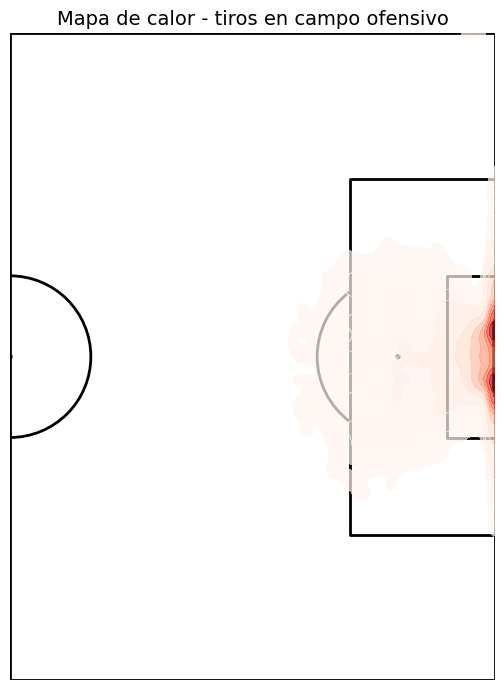

In [11]:
# Extraer tiros
shots = events_df[events_df['type'] == 'Shot'].dropna(subset=['shot_end_location']).copy()
shots[['x','y','z']] = pd.DataFrame(shots['shot_end_location'].tolist(), index=shots.index)

# Contar totales
total_shots = len(shots)
total_goals = shots['shot_outcome'].eq('Goal').sum()

print(f"Total de tiros: {total_shots}")
print(f"Total de goles: {total_goals}")

# Crear cancha (StatsBomb 120x80)
pitch = Pitch(pitch_type='statsbomb', line_color='black')
fig, ax = pitch.draw(figsize=(10,7))

# Graficar solo medio campo ofensivo (x de 60 a 120)
ax.set_xlim(60, 120)
ax.set_ylim(0, 80)

# Heatmap
sns.kdeplot(
    x=shots['x'], y=shots['y'],
    fill=True, cmap="Reds", bw_adjust=0.5, alpha=0.7, ax=ax
)

ax.set_title("Mapa de calor - tiros en campo ofensivo", fontsize=14)
plt.show()

ANÁLISIS GRÁFICO Y DESCRIPTIVO: Entonces podemos ver el heatmap y ver que muchos de los tiros fueron al arco o cerca por la intesidad del calor, entonces a continuacion se grafica en un grafico de 3 dimensiones de puntos, todos los tiros en gris y en verde solo los que fueron goles

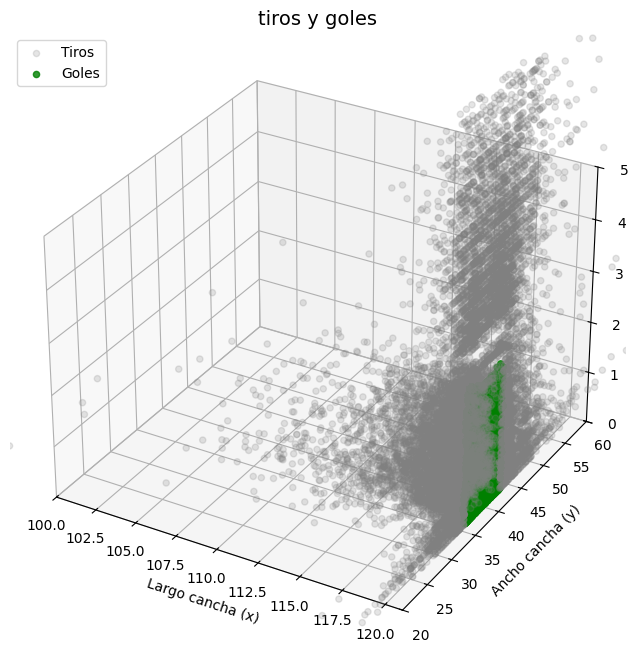

In [12]:
# Filtrar tiros y extraer coords
shots = events_df[events_df['type'] == 'Shot'].dropna(subset=['shot_end_location']).copy()
shots[['x','y','z']] = pd.DataFrame(shots['shot_end_location'].tolist(), index=shots.index)

# Separar goles y no goles
goals = shots[shots['shot_outcome'] == 'Goal']
no_goals = shots[shots['shot_outcome'] != 'Goal']

# Crear gráfico 3D
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

# Tiros en gris
ax.scatter(no_goals['x'], no_goals['y'], no_goals['z'], 
           c='gray', alpha=0.2, label='Tiros')

# Goles en verde
ax.scatter(goals['x'], goals['y'], goals['z'], 
           c='green', alpha=0.8, label='Goles')

# Ajustar límites más amplios que antes (zoom intermedio)
ax.set_xlim(100, 121)   # antes era 110–121
ax.set_ylim(20, 60)     # antes era 30–50
ax.set_zlim(0, 5)       # antes era 0–3

# Etiquetas
ax.set_xlabel("Largo cancha (x)")
ax.set_ylabel("Ancho cancha (y)")
ax.set_zlabel("Altura (z)")
ax.set_title("tiros y goles", fontsize=14)

ax.legend()
plt.show()

Analisis de correlaciones: 

EJEMPLO DE MATRIZ CON RUIDO DE TODAS LAS VARIABLES

Como ejemplo se realizo un estudio posesion vs goles con la duda de si más posesión implica más goles. Primero se debe crear un dataset por partido agrupando la información a nivel de partido y equipo, resumiendo:

Posesión promedio.

Cantidad de goles anotados.

In [13]:
# Filtrar eventos con posesión y goles
df = events_df.copy()

# Crear columna de goles (1 si fue gol, 0 en caso contrario)
df['is_goal'] = (df['shot_outcome'] == 'Goal').astype(int)

# Agrupar por partido y equipo
team_stats = df.groupby(['match_id','team']).agg(
    possession_avg=('possession', 'mean'),   # promedio de posesión
    goals=('is_goal', 'sum')                 # goles marcados
).reset_index()

print(team_stats.head())


   match_id              team  possession_avg  goals
0      9575         Barcelona       81.205818      1
1      9575        Real Betis       82.930454      0
2      9581         Barcelona       83.948490      2
3      9581  Deportivo Alavés       97.968254      0
4      9592         Barcelona       80.653280      5


análisis gráfico

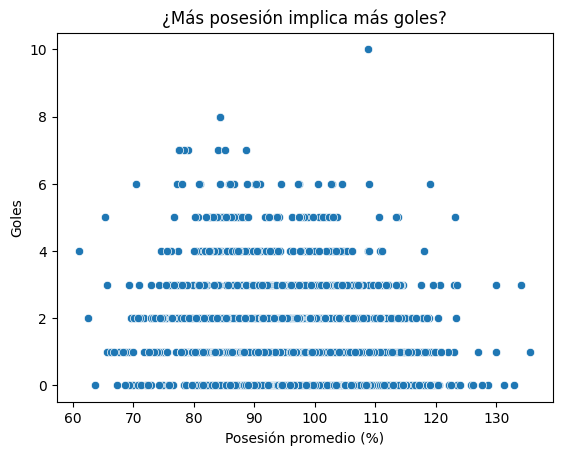

In [14]:
# Dispersión posesión vs goles
sns.scatterplot(x="possession_avg", y="goals", data=team_stats)
plt.title("¿Más posesión implica más goles?")
plt.xlabel("Posesión promedio (%)")
plt.ylabel("Goles")
plt.show()

correlación numérica del resultado grafico previo

In [15]:
# Correlación lineal
corr = team_stats['possession_avg'].corr(team_stats['goals'])
print(f"Correlación posesión vs goles: {corr:.2f}")


Correlación posesión vs goles: -0.16


Interpretación:

Si la correlación está cerca de 0 → no hay relación lineal clara (puede que equipos con más posesión no siempre marquen más).

Si es positiva → más posesión suele ir con más goles.

Si es negativa → más posesión no necesariamente significa más goles (ej: equipos que dominan pero no concretan).

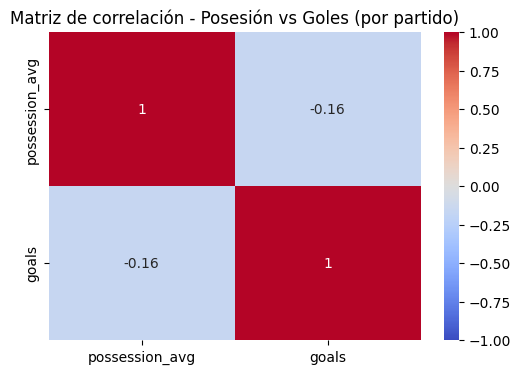

In [16]:

# Seleccionar solo las variables numéricas de interés
corr_vars = team_stats[['possession_avg', 'goals']]

# Calcular matriz de correlación
corr_matrix = corr_vars.corr()

# Graficar
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriz de correlación - Posesión vs Goles (por partido)", fontsize=12)
plt.show()


Matriz de correlacion 4x4: donde el xG (expectativa de gol) es la variable que realmente incide en la capacidad de hacer goles de un equipo o jugador

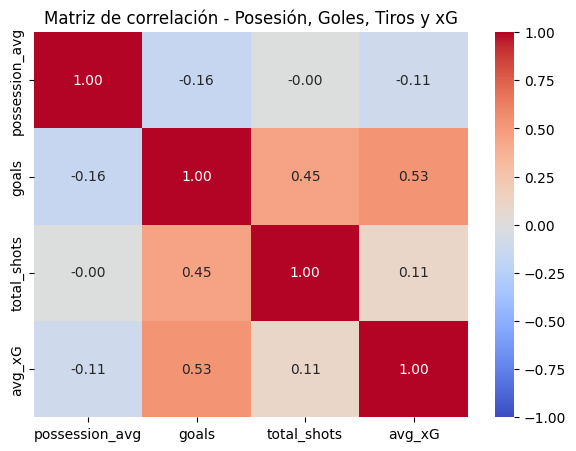

In [17]:
# Copia del dataframe de eventos
df = events_df.copy()

# Columna binaria de goles
df['is_goal'] = (df['shot_outcome'] == 'Goal').astype(int)

# Agrupar por partido y equipo
team_stats = df.groupby(['match_id','team']).agg(
    possession_avg=('possession','mean'),
    goals=('is_goal','sum'),
    total_shots=('id', lambda x: (df.loc[x.index, 'type'] == 'Shot').sum()),
    avg_xG=('shot_statsbomb_xg', 'mean')
).reset_index()

# Seleccionamos solo las variables numéricas de interés
corr_vars = team_stats[['possession_avg', 'goals', 'total_shots', 'avg_xG']]

# Calcular matriz de correlación
corr_matrix = corr_vars.corr()

# Graficar heatmap
plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de correlación - Posesión, Goles, Tiros y xG", fontsize=12)
plt.show()


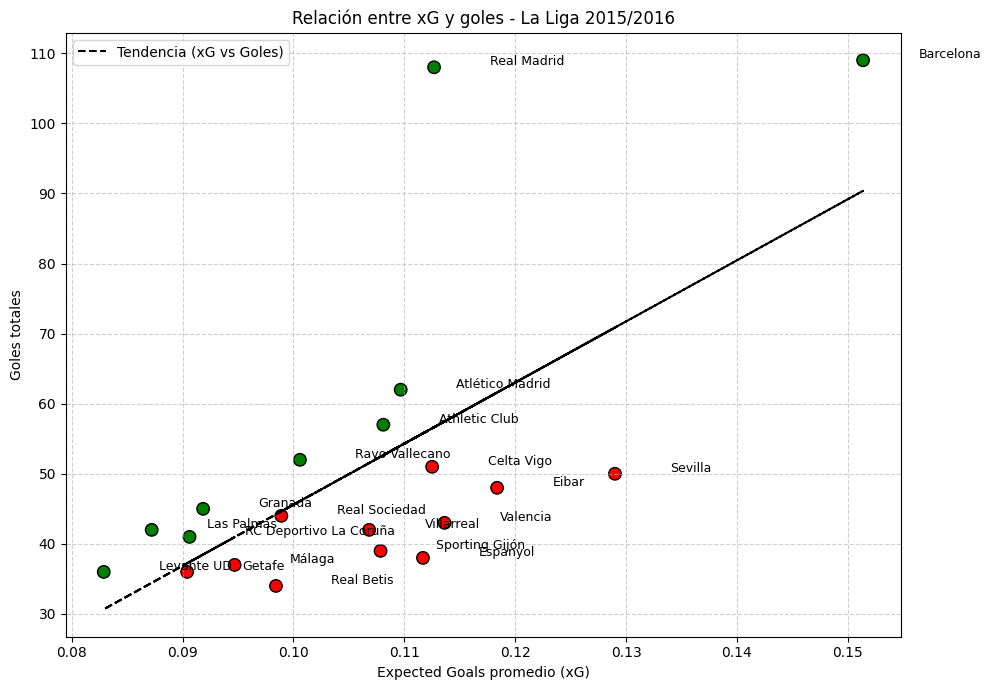

In [18]:
# 1. Filtrar solo La Liga 2015/2016 en matches
matches_2015 = matches_df[(matches_df['competition_id']==11) & (matches_df['season_id']==27)].copy()

# 2. Unir con events para traer los eventos de esos partidos
season_2015 = events_df.merge(
    matches_2015[['match_id','season_id','competition_id','home_team','away_team']], 
    on='match_id', how='inner'
)

# 3. Crear columna binaria de goles
season_2015['is_goal'] = (season_2015['shot_outcome'] == 'Goal').astype(int)

# 4. Agrupar por equipo
team_stats_2015 = season_2015.groupby('team').agg(
    goals=('is_goal','sum'),
    avg_xG=('shot_statsbomb_xg','mean')
).reset_index()

# --- Graficar dispersión ---
x = team_stats_2015['avg_xG']
y = team_stats_2015['goals']

plt.figure(figsize=(10,7))

# 5. Línea de regresión lineal
m, b = np.polyfit(x, y, 1)  # pendiente y ordenada
plt.plot(x, m*x + b, color="black", linestyle="--", label="Tendencia (xG vs Goles)")

# 6. Asignar color según rendimiento
colors = ['green' if actual > (m*exp + b) else 'red' for exp, actual in zip(x, y)]

plt.scatter(x, y, c=colors, s=80, edgecolors="k")

# 7. Etiquetas con nombres completos
for i, row in team_stats_2015.iterrows():
    plt.text(row['avg_xG']+0.005, row['goals']+0.3, row['team'], fontsize=9)

# Personalización
plt.xlabel("Expected Goals promedio (xG)")
plt.ylabel("Goles totales")
plt.title("Relación entre xG y goles - La Liga 2015/2016")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()




Matriz de correlacion de la mayoria de las variables de events

✅ Dataset reducido cargado: (156675, 119)


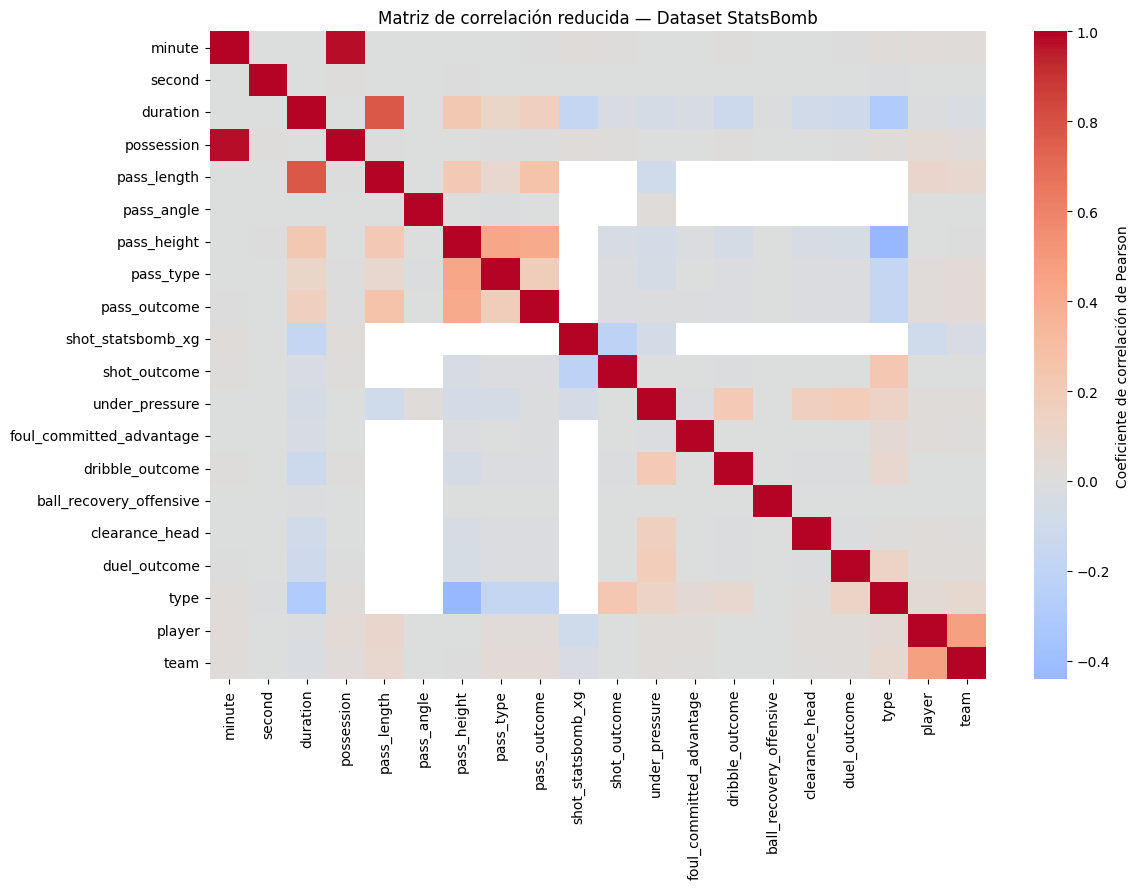


🔹 Correlaciones más fuertes (>|0.4|):
possession    minute         0.974226
duration      pass_length    0.773944
team          player         0.461669
pass_height   pass_type      0.432618
pass_outcome  pass_height    0.404802
pass_height   type          -0.440889
dtype: float64


In [19]:
# =======================
# 1️⃣ Filtrado y muestreo ligero
# =======================

# 🔹 Tomamos solo una fracción del dataset para evitar desbordar memoria
df_corr = events_df.sample(frac=0.05, random_state=42)  # 5% del dataset
print(f"✅ Dataset reducido cargado: {df_corr.shape}")

# 🔹 Eliminamos columnas anidadas o extremadamente pesadas
cols_descartar = [
    'location', 'pass_end_location', 'carry_end_location',
    'shot_end_location', 'shot_freeze_frame', 'tactics', 'related_events'
]
df_corr = df_corr.drop(columns=cols_descartar, errors='ignore')

# =======================
# 2️⃣ Mantener solo columnas útiles y codificables
# =======================
# Seleccionamos columnas clave con significado analítico
cols_utiles = [
    'minute', 'second', 'duration', 'possession',
    'pass_length', 'pass_angle', 'pass_height', 'pass_type', 'pass_outcome',
    'shot_statsbomb_xg', 'shot_outcome', 'under_pressure', 'foul_committed_advantage',
    'dribble_outcome', 'ball_recovery_offensive', 'clearance_head', 'duel_outcome',
    'type', 'player', 'team'
]

df_corr = df_corr[[c for c in cols_utiles if c in df_corr.columns]]

# =======================
# 3️⃣ Codificar categóricas en forma liviana
# =======================
for col in df_corr.select_dtypes(include=['object', 'bool']).columns:
    df_corr[col] = pd.factorize(df_corr[col])[0]

# =======================
# 4️⃣ Calcular matriz de correlación
# =======================
corr_matrix = df_corr.corr(method='pearson')

# =======================
# 5️⃣ Visualización resumida
# =======================
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    cbar_kws={'label': 'Coeficiente de correlación de Pearson'},
    xticklabels=True,
    yticklabels=True
)
plt.title("Matriz de correlación reducida — Dataset StatsBomb")
plt.tight_layout()
plt.show()

# =======================
# 6️⃣ Mostrar correlaciones más fuertes
# =======================
corr_unstacked = corr_matrix.unstack().sort_values(ascending=False)
strong_corr = corr_unstacked[
    (abs(corr_unstacked) >= 0.4) & (corr_unstacked < 1)
].drop_duplicates()

print("\n🔹 Correlaciones más fuertes (>|0.4|):")
print(strong_corr.head(25))

4.PREPARACION DE DATOS PARA ML

4.1.LIMPIEZA DE DATOS

Primero definimos y generamos agg_df (dataset agregado)-> tabla resumen donde cada fila representa una unidad de análisis (por ejemplo, un equipo por temporada)
y las columnas contienen métricas estadísticas resumidas derivadas de los datos originales (eventos). Mientras que events_df contiene millones de filas (cada pase, tiro, recuperación, etc.), agg_df resume toda esa información a un nivel superior (por equipo y temporada),
convirtiendo datos de eventos en indicadores de rendimiento.

El proposito de crear esto:
1-Reducir complejidad — pasar de millones de filas a decenas o centenas sin perder información esencial.
2-Facilitar análisis estadístico y ML, ya que los algoritmos requieren entradas tabulares.
3-Comparar unidades entre sí (equipos, temporadas, jugadores, etc.) usando métricas comunes.
4-Detectar patrones globales: eficiencia, estilos de juego, rendimiento ofensivo o defensivo.

In [20]:
# =====================================
# 0️⃣ Preparación base
# =====================================
# Asegurate de tener:
# - events_df  (cargado con eventos StatsBomb)
# - matches_df (para unir season_id y competition_id)
# =====================================

# Unir datos para asegurar season_id y competition_id
df = events_df.merge(
    matches_df[['match_id', 'season_id', 'competition_id']],
    on='match_id',
    how='left'
)

# Crear variable binaria de goles
df['is_goal'] = (df['shot_outcome'] == 'Goal').astype(int)

# =====================================
# 1️⃣ MÉTRICAS OFENSIVAS
# =====================================

# ---- PASES ----
passes = df[df['type'] == 'Pass']
passes_grouped = passes.groupby(['season_id', 'team']).agg(
    total_passes=('id', 'count'),
    completed_passes=('pass_outcome', lambda x: x.isna().sum()),  # isna = pase completo
    avg_pass_length=('pass_length', 'mean')
).reset_index()

# Precisión de pase
passes_grouped['pass_accuracy'] = (
    passes_grouped['completed_passes'] / passes_grouped['total_passes']
).fillna(0)

# ---- TIROS ----
shots = df[df['type'] == 'Shot']
shots_grouped = shots.groupby(['season_id', 'team']).agg(
    total_shots=('id', 'count'),
    goals=('is_goal', 'sum'),
    avg_xG=('shot_statsbomb_xg', 'mean')
).reset_index()

# ---- POSESIÓN ----
possession_grouped = df.groupby(['season_id', 'team']).agg(
    avg_possession=('possession', 'mean')
).reset_index()

# =====================================
# 2️⃣ MÉTRICAS DEFENSIVAS
# =====================================
defensive_metrics = df[df['type'].isin(['Duel', 'Interception', 'Clearance', 'Foul Committed'])].groupby(
    ['season_id', 'team']
).agg(
    duels_won=('duel_outcome', lambda x: (x == 'Won').sum()),
    duels_total=('duel_outcome', 'count'),
    interceptions=('type', lambda x: (x == 'Interception').sum()),
    clearances=('type', lambda x: (x == 'Clearance').sum()),
    fouls_committed=('type', lambda x: (x == 'Foul Committed').sum())
).reset_index()

defensive_metrics['duel_win_rate'] = (
    defensive_metrics['duels_won'] / defensive_metrics['duels_total']
).replace([float('inf'), None], 0)

# =====================================
# 3️⃣ MÉTRICAS TÁCTICAS
# =====================================
if 'counterpress' in df.columns:
    tactical_metrics = df.groupby(['season_id', 'team']).agg(
        counterpress_events=('counterpress', 'sum'),
        avg_possession=('possession', 'mean')
    ).reset_index()
else:
    tactical_metrics = df.groupby(['season_id', 'team']).agg(
        avg_possession=('possession', 'mean')
    ).reset_index()
    tactical_metrics['counterpress_events'] = 0

# =====================================
# 4️⃣ UNIFICACIÓN FINAL
# =====================================
agg_df = passes_grouped.merge(shots_grouped, on=['season_id', 'team'], how='outer')
agg_df = agg_df.merge(possession_grouped, on=['season_id', 'team'], how='outer')
agg_df = agg_df.merge(defensive_metrics, on=['season_id', 'team'], how='outer')
agg_df = agg_df.merge(tactical_metrics, on=['season_id', 'team'], how='outer')

agg_df.fillna(0, inplace=True)

# =====================================
# 5️⃣ VALIDACIÓN
# =====================================
print(f"✅ agg_df reconstruido: {agg_df.shape[0]} equipos/temporadas, {agg_df.shape[1]} variables")
display(agg_df.head(10))



✅ agg_df reconstruido: 322 equipos/temporadas, 18 variables


,season_id,team,total_passes,completed_passes,avg_pass_length,pass_accuracy,total_shots,goals,avg_xG,avg_possession_x,duels_won,duels_total,interceptions,clearances,fouls_committed,duel_win_rate,counterpress_events,avg_possession_y
0,1,Athletic Club,842,624,23.430556,0.741093,27,0,0.072055,105.206841,11,42,50,23,36,0.261905,155,105.206841
1,1,Atlético Madrid,837,637,20.645761,0.761051,10,1,0.059274,101.546020,11,65,61,34,41,0.169231,121,101.546020
2,1,Barcelona,24158,20893,18.937971,0.864848,547,90,0.136709,90.039684,152,553,470,483,419,0.274864,2195,90.039684
3,1,Celta Vigo,919,721,20.888169,0.784548,28,4,0.145847,92.080930,8,38,33,30,24,0.210526,132,92.080930
4,1,Deportivo Alavés,534,353,26.080608,0.661049,18,1,0.079795,102.621977,18,52,43,50,40,0.346154,112,102.621977
5,1,Eibar,933,714,24.748963,0.765273,27,1,0.063366,99.150381,11,45,49,14,29,0.244444,92,99.150381
6,1,Espanyol,507,311,23.902871,0.613412,16,1,0.064624,88.985461,10,43,32,48,40,0.232558,103,88.985461
7,1,Getafe,539,338,26.880617,0.627087,23,1,0.045616,80.848135,21,50,49,38,44,0.420000,100,80.848135
8,1,Girona,769,583,23.225212,0.758127,24,1,0.077148,97.404467,11,33,38,22,34,0.333333,107,97.404467
9,1,Las Palmas,924,765,20.492213,0.827922,23,1,0.078563,91.304385,13,42,23,28,34,0.309524,77,91.304385


In [21]:
# Unificamos si existen duplicados por el merge
if 'avg_possession_x' in agg_df.columns:
    agg_df['avg_possession'] = agg_df['avg_possession_x']
    agg_df.drop(columns=['avg_possession_x', 'avg_possession_y'], errors='ignore', inplace=True)

4.2.Escalado de datos

In [25]:
# Variables numéricas a escalar
features = ['offensive_score', 'defensive_score', 'tactical_score', 'performance_score']

# Pipeline de preprocesamiento (solo escalado)
scaling_pipeline = Pipeline([
    ('scaler', RobustScaler(quantile_range=(10, 90)))  # menos sensible a valores extremos
])

# Aplicar pipeline
X_scaled = scaling_pipeline.fit_transform(df_model[features])

# Guardar DataFrame escalado (por si lo querés inspeccionar)
df_scaled = df_model.copy()
df_scaled[[f"{f}_scaled" for f in features]] = X_scaled

print("✅ Escalado de datos completado")
display(df_scaled.head(5))

✅ Escalado de datos completado


,season_id,team,total_passes_x,completed_passes_x,avg_pass_length,pass_accuracy_x,total_shots_x,goals_x,avg_xG,duels_won,...,tac__pattern_entropy,tac__tactics_pm,tac__pass_accuracy,offensive_score,tactical_score,performance_score,offensive_score_scaled,defensive_score_scaled,tactical_score_scaled,performance_score_scaled
0,1,Athletic Club,842,624,23.430556,0.741093,27,0,0.072055,11,...,0.408309,0.000000,0.571165,0.171844,0.408075,0.353745,-0.230108,0.885595,-0.177697,0.035475
1,1,Atlético Madrid,837,637,20.645761,0.761051,10,1,0.059274,11,...,0.163250,0.500000,0.627764,0.149084,0.462857,0.321824,-0.292365,0.342284,0.020784,-0.124125
2,1,Barcelona,24158,20893,18.937971,0.864848,547,90,0.136709,152,...,0.470977,0.211111,0.922114,0.559826,0.644573,0.545458,0.831193,0.552053,0.679158,0.994026
3,1,Celta Vigo,919,721,20.888169,0.784548,28,4,0.145847,8,...,0.210553,0.200000,0.694398,0.475310,0.450365,0.468497,0.600004,0.374002,-0.024477,0.609227
4,1,Deportivo Alavés,534,353,26.080608,0.661049,18,1,0.079795,18,...,0.392885,0.200000,0.344174,0.196935,0.329952,0.313421,-0.161472,0.160532,-0.460745,-0.166143


5.Modelos de ML

5.1.Clustering

Teniendo este modelo podemos comenzar con el clustering para conseguir clusters (k) de equipos BUENOS, INTERMEDIOS y MALOS en base a un modelo completo que contemple informacion defensiva, ofensiva y tactica.

Cada una de estas variables (defensivo, ofensivo, tactico) en su totalidad por cada equipo generó un 'performance_score' el cual deriva de un 'score' individual de las mencionadas previamente, donde a traves de una seleccion optima de variables y el juego del peso de unas sobre otras se lograron obtener 3 clusters que determinan el nivel de cada equipo que lo compone (BUENO, INTERMEDIO, MALO).

In [23]:
#se valida el agregado de la variable cronologica (season_id)
if 'season_id' not in events_df.columns and 'matches_df' in globals():
    ev = events_df.merge(matches_df[['match_id', 'season_id']], on='match_id', how='left')
else:
    ev = events_df.copy()

#variables que definen los SCORES
cols_keep = [
    'match_id','season_id','team','type','shot_statsbomb_xg','shot_outcome',
    'pass_goal_assist','pass_shot_assist',
    'ball_recovery_recovery_failure','counterpress',
    'duel_outcome','foul_committed_card', 'play_pattern', 'tactics',
    'pass_outcome','pass_length'
]
for c in cols_keep:
    if c not in ev.columns:
        ev[c] = np.nan
ev = ev[cols_keep].copy()

#eventos derivados
# Helper flags
ev['is_goal']              = (ev['shot_outcome'] == 'Goal').astype('int64')
ev['is_shot']              = (ev['type'] == 'Shot').astype('int64')
ev['is_pass_goal_assist']  = ev['pass_goal_assist'].fillna(False).astype('int64')
ev['is_pass_shot_assist']  = ev['pass_shot_assist'].fillna(False).astype('int64')
ev['is_recovery_fail']     = ev['ball_recovery_recovery_failure'].fillna(False).astype('int64')
ev['is_counterpress']      = ev['counterpress'].fillna(False).astype('int64')

# Duelos
ev['duel_won']   = (ev['duel_outcome'] == 'Won').astype('int64')
ev['duel_lost']  = (ev['duel_outcome'] == 'Lost').astype('int64')
ev['duel_foul']  = (ev['duel_outcome'] == 'Foul Committed').astype('int64')

# Faltas (evento de falta cometida)
ev['is_foul_committed'] = (ev['type'] == 'Foul Committed').astype('int64')

#Partidos por equipo-temporada (para tasas por partido)
games = ev.groupby(['season_id','team'])['match_id'].nunique().rename('games')

#Métricas OFENSIVAS
#goals, xG, shots, pass_goal_assist, pass_shot_assist
off_g = ev.groupby(['season_id','team']).agg(
    goals=('is_goal', 'sum'),
    total_shots=('is_shot', 'sum'),
    xg_sum=('shot_statsbomb_xg','sum'),
    shot_assists=('is_pass_shot_assist','sum'),
    goal_assists=('is_pass_goal_assist','sum')
).reset_index()

off_g = off_g.merge(games, on=['season_id','team'], how='left').fillna({'games':1})

# Tasas por partido
off_g['goals_pm']         = off_g['goals']        / off_g['games']
off_g['shots_pm']         = off_g['total_shots']  / off_g['games']
off_g['shot_assists_pm']  = off_g['shot_assists'] / off_g['games']
off_g['goal_assists_pm']  = off_g['goal_assists'] / off_g['games']
# xG medio por tiro (calidad, no volumen)
off_g['xg_per_shot'] = np.where(off_g['total_shots']>0,
                                off_g['xg_sum']/off_g['total_shots'], 0.0)

#Métricas DEFENSIVAS
#recovery_failure penaliza
#counterpress suma
#duel_outcome: won (+), lost (-), foul (--)
def_g = ev.groupby(['season_id','team']).agg(
    counterpress_events=('is_counterpress', 'sum'),
    recovery_fail=('is_recovery_fail','sum'),
    duel_won=('duel_won','sum'),
    duel_lost=('duel_lost','sum'),
    duel_foul=('duel_foul','sum'),
    fouls_committed=('is_foul_committed','sum')
).reset_index()

def_g = def_g.merge(games, on=['season_id','team'], how='left').fillna({'games':1})

# Tasas y ratios
def_g['counterpress_pm']   = def_g['counterpress_events'] / def_g['games']
def_g['recovery_fail_pm']  = def_g['recovery_fail']       / def_g['games']
duel_tot = (def_g['duel_won'] + def_g['duel_lost']).replace(0, np.nan)
def_g['duel_win_rate']     = (def_g['duel_won'] / duel_tot).fillna(0.0)
def_g['duel_foul_pm']      = def_g['duel_foul'] / def_g['games']
def_g['fouls_committed_pm']= def_g['fouls_committed'] / def_g['games']


#Métricas TÁCTICAS
# play_pattern (entropía como variedad táctica)
# tactics (conteo de cambios/formaciones reportadas)
# pass_accuracy
passes = ev[ev['type'] == 'Pass'].copy()

# En StatsBomb: pass_outcome NaN suele significar pase completado
passes['completed'] = passes['pass_outcome'].isna().astype('int64')

# Por si en algún dataset 'team' viene con otro nombre, aseguramos su presencia
assert 'team' in passes.columns, "No encuentro la columna 'team' en events/passes."

pa = passes.groupby(['season_id', 'team']).agg(
    total_passes=('match_id','count'),
    completed_passes=('completed','sum')
).reset_index()

pa['pass_accuracy'] = np.where(pa['total_passes'] > 0,
                               pa['completed_passes'] / pa['total_passes'], 0.0)

# Entropía de play_pattern (0=monótono, 1=muy variado)
pp = ev.dropna(subset=['play_pattern']).groupby(['season_id','team'])['play_pattern'].value_counts(normalize=True)
pp = pp.rename('p').reset_index()
pp['h'] = -pp['p']*np.log(pp['p'])
ent = pp.groupby(['season_id','team']).agg(
    pattern_entropy=('h','sum'),
    pattern_unique=('play_pattern','nunique')
).reset_index()
# Normalizamos entropía por el máximo posible log(n) para que quede 0..1
ent['pattern_entropy'] = np.where(ent['pattern_unique']>1,
                                  ent['pattern_entropy']/np.log(ent['pattern_unique']),
                                  0.0)
ent = ent[['season_id','team','pattern_entropy']]

# 'tactics' (cambios/registro táctico no nulo)
tac = ev.copy()
tac['has_tactics'] = tac['tactics'].apply(lambda x: 1 if isinstance(x, dict) or pd.notna(x) else 0)
tac = tac.groupby(['season_id','team']).agg(tactics_events=('has_tactics','sum')).reset_index()
tac = tac.merge(games, on=['season_id','team'], how='left')
tac['tactics_pm'] = tac['tactics_events']/tac['games']
tac = tac[['season_id','team','tactics_pm']]

#Unimos TODO al agg_df original
df_model = agg_df.copy()

for tbl in [off_g, def_g, pa, ent, tac]:
    df_model = df_model.merge(tbl, on=['season_id','team'], how='left')

df_model.fillna(0, inplace=True)

# Normalización (0..1) de las métricas atómicas para ponderar justo
def minmax(s):
    s = s.astype('float64')
    lo, hi = s.min(), s.max()
    return (s - lo)/(hi - lo) if hi > lo else 0.0

# OFENSIVO
df_model['off__goals_pm']        = minmax(df_model['goals_pm'])
df_model['off__xg_per_shot']     = minmax(df_model['xg_per_shot'])
df_model['off__shots_pm']        = minmax(df_model['shots_pm'])
df_model['off__goal_assists_pm'] = minmax(df_model['goal_assists_pm'])
df_model['off__shot_assists_pm'] = minmax(df_model['shot_assists_pm'])

#tst 
# --- 0) Helpers
def minmax(s):
    s = s.astype(float)
    rng = s.max() - s.min()
    return (s - s.min()) / (rng if rng != 0 else 1)

# --- 1) Asegurar season_id en events
if 'season_id' not in events_df.columns:
    ev = events_df.merge(matches_df[['match_id','season_id']], on='match_id', how='left')
else:
    ev = events_df.copy()

grp = ['season_id','team']

# Total de eventos por equipo-temporada (para normalizar "por 1000 eventos")
events_count = ev.groupby(grp).size().rename('events_total')

# --- 2) DUELS: win rate, faltas en duelo
duels = (ev[ev['type']=='Duel']
         .groupby(grp)['duel_outcome']
         .value_counts()
         .unstack(fill_value=0))

# asegurar columnas que a veces faltan
for col in ['Won','Lost','Foul Committed']:
    if col not in duels.columns:
        duels[col] = 0

duels = duels.reset_index()
duels['duels_total'] = duels[['Won','Lost','Foul Committed']].sum(axis=1)
duels['duels_won']   = duels['Won']
duels['duel_foul']   = duels['Foul Committed']
duels['duel_win_rate'] = (duels['duels_won'] / duels['duels_total']).fillna(0.0)

# --- 3) Counterpress (eventos con flag True)
cp = (ev['counterpress'] == True).groupby([ev[c] for c in grp]).sum().rename('counterpress')

# --- 4) Ball recovery failure
br_fail = (ev['ball_recovery_recovery_failure'] == True).groupby([ev[c] for c in grp]).sum().rename('recovery_fail')

# --- 5) Faltas cometidas (cualquier tipo)
fouls = (ev['type'] == 'Foul Committed').groupby([ev[c] for c in grp]).sum().rename('fouls_committed')

# --- 6) Unir y crear tasas por 1000 eventos
def_metrics = (
    duels.set_index(grp)[['duel_win_rate','duel_foul','duels_total']]
    .join([cp, br_fail, fouls, events_count], how='outer')
    .fillna(0)
    .reset_index()
)

for col in ['counterpress','recovery_fail','duel_foul','fouls_committed']:
    def_metrics[col + '_p1k'] = 1000 * def_metrics[col] / def_metrics['events_total'].replace({0:1})

# --- 7) Incorporar al df_model
df_model = df_model.merge(
    def_metrics[grp + ['duel_win_rate','counterpress_p1k','recovery_fail_p1k','duel_foul_p1k','fouls_committed_p1k']],
    on=grp, how='left'
).fillna(0)

# --- 8) Columnas defensivas normalizadas (sin espacios en nombres)
df_model['def_duel_win_rate']   = minmax(df_model['duel_win_rate'])                 # + bueno
df_model['def_counterpress_p1k']= minmax(df_model['counterpress_p1k'])              # + bueno (si lo tratás como presión exitosa)
df_model['def_recovery_fail_p1k']= minmax(df_model['recovery_fail_p1k']) * (-1)     # - malo
df_model['def_duel_foul_p1k']   = minmax(df_model['duel_foul_p1k']) * (-1)          # - malo
df_model['def_fouls_comm_p1k']  = minmax(df_model['fouls_committed_p1k']) * (-1)    # - malo

# ejemplo de defensive_score combinando señales (+ subí ponderaciones a gusto)
df_model['defensive_score'] = (
    0.45*df_model['def_duel_win_rate'] +
    0.20*df_model['def_counterpress_p1k'] +
    0.20*df_model['def_recovery_fail_p1k'] +
    0.10*df_model['def_duel_foul_p1k'] +
    0.05*df_model['def_fouls_comm_p1k']
)

#tst 

# DEFENSIVO (ganar duelos +, perder posesion recovery_fail - , counterpress (contrapresión) +)
df_model['def__duel_win_rate']    = minmax(df_model['duel_win_rate'])
df_model['def__counterpress_pm']  = minmax(df_model['counterpress_pm'])
df_model['def__recovery_fail_pm'] = minmax(df_model['recovery_fail_pm'])   
df_model['def__duel_foul_pm']     = minmax(df_model['duel_foul_pm'])      
df_model['def__fouls_committed_pm']= minmax(df_model['fouls_committed_pm'])

#tst 
if 'pass_accuracy' not in df_model.columns:
    if 'season_id' not in events_df.columns and 'matches_df' in globals():
        ev = events_df.merge(matches_df[['match_id', 'season_id']], on='match_id', how='left')
    else:
        ev = events_df.copy()

    passes = ev[ev['type'] == 'Pass'].copy()

    # En StatsBomb, pass_outcome NaN normalmente indica pase completado
    passes['completed'] = passes['pass_outcome'].isna().astype(int)

    pa = passes.groupby(['season_id', 'team']).agg(
        total_passes=('match_id', 'count'),
        completed_passes=('completed', 'sum')
    ).reset_index()

    pa['pass_accuracy'] = np.where(pa['total_passes'] > 0,
                                   pa['completed_passes'] / pa['total_passes'],
                                   0.0)

    # Incorporar al df_model
    df_model = df_model.merge(pa[['season_id', 'team', 'pass_accuracy']],
                              on=['season_id', 'team'],
                              how='left').fillna({'pass_accuracy': 0})

else:
    print("✅ 'pass_accuracy' ya existe en df_model.")
#tst 

# TÁCTICO (variedad, ajustes, precisión de pase opcional)
df_model['tac__pattern_entropy'] = minmax(df_model['pattern_entropy'])
df_model['tac__tactics_pm']      = minmax(df_model['tactics_pm'])
df_model['tac__pass_accuracy']   = minmax(df_model['pass_accuracy'])  # si no querés usarla, poné peso 0

#Sub-scores 
# --- OFENSIVO ---
df_model['offensive_score'] = (
    0.40 * df_model['off__goals_pm'] +
    0.30 * df_model['off__xg_per_shot'] +
    0.15 * df_model['off__shots_pm'] +
    0.10 * df_model['off__goal_assists_pm'] +
    0.05 * df_model['off__shot_assists_pm']
)

# --- DEFENSIVO ---
df_model['defensive_score'] = (
    0.40 * df_model['def__duel_win_rate'] +
    0.25 * df_model['def__counterpress_pm'] +
   -0.20 * df_model['def__recovery_fail_pm'] +
   -0.10 * df_model['def__fouls_committed_pm'] +
   -0.05 * df_model['def__duel_foul_pm']
)

# --- TÁCTICO ---
df_model['tactical_score'] = (
    0.30 * df_model['tac__pattern_entropy'] +
    0.20 * df_model['tac__tactics_pm'] +
    0.50 * df_model['tac__pass_accuracy']
)


# 8) Performance global
df_model['performance_score'] = (
    0.45 * df_model['offensive_score'] +
    0.40 * df_model['defensive_score'] +
    0.15 * df_model['tactical_score']
)

# Vista rápida
cols_preview = [
    'team','season_id',
    'offensive_score','defensive_score','tactical_score','performance_score',
    # opcional: métricas base para chequear
    'goals_pm','xg_per_shot','shots_pm','goal_assists_pm','shot_assists_pm',
    'duel_win_rate','counterpress_pm','recovery_fail_pm','fouls_committed_pm','duel_foul_pm',
    'pattern_entropy','tactics_pm','pass_accuracy'
]
display(df_model[cols_preview].sort_values('performance_score', ascending=False).head(15))

C:\Users\Tomas\AppData\Local\Temp\ipykernel_27392\51801563.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ev['is_pass_goal_assist']  = ev['pass_goal_assist'].fillna(False).astype('int64')
C:\Users\Tomas\AppData\Local\Temp\ipykernel_27392\51801563.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ev['is_pass_shot_assist']  = ev['pass_shot_assist'].fillna(False).astype('int64')
C:\Users\Tomas\AppData\Local\Temp\ipykernel_27392\51801563.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in

,team,season_id,offensive_score,defensive_score,tactical_score,performance_score,goals_pm,xg_per_shot,shots_pm,goal_assists_pm,shot_assists_pm,duel_win_rate,counterpress_pm,recovery_fail_pm,fouls_committed_pm,duel_foul_pm,pattern_entropy,tactics_pm,pass_accuracy
256,Real Madrid,40,0.749417,0.516146,0.514921,0.620934,4.000000,0.123211,20.000000,2.000000,12.000000,1.0,56.000000,0.000000,13.000000,0.0,0.663489,1.000000,0.833977
102,Barcelona,23,0.611198,0.485241,0.632015,0.563938,2.918919,0.134845,16.324324,1.891892,9.864865,1.0,62.297297,3.216216,12.108108,0.0,0.673642,2.324324,0.870358
163,Barcelona,26,0.605095,0.491823,0.628988,0.563370,2.842105,0.134527,16.447368,1.921053,9.789474,1.0,61.315789,2.894737,10.736842,0.0,0.689441,1.763158,0.870295
22,Barcelona,2,0.616186,0.474186,0.642388,0.563316,3.000000,0.131372,16.588235,1.823529,9.970588,1.0,58.382353,2.970588,12.176471,0.0,0.711465,1.676471,0.863011
194,Real Madrid,27,0.626288,0.465956,0.617452,0.560830,2.842105,0.112685,18.868421,2.210526,12.289474,1.0,56.447368,2.842105,13.078947,0.0,0.696719,2.105263,0.846170
182,Barcelona,27,0.619132,0.469748,0.624973,0.560254,2.868421,0.151380,15.894737,2.026316,9.236842,1.0,55.578947,2.789474,11.210526,0.0,0.704612,1.526316,0.860933
122,Barcelona,24,0.601600,0.488741,0.623889,0.559800,3.000000,0.126979,13.531250,2.312500,7.718750,1.0,63.125000,3.250000,11.843750,0.0,0.669066,1.968750,0.878643
267,Barcelona,41,0.626298,0.463211,0.576965,0.553663,2.935484,0.125795,18.580645,1.870968,11.161290,1.0,59.612903,3.516129,13.935484,0.0,0.679462,2.161290,0.831064
2,Barcelona,1,0.559826,0.492126,0.644573,0.545458,2.500000,0.136709,15.194444,1.916667,8.861111,1.0,60.972222,2.638889,11.638889,0.0,0.698845,2.055556,0.864848
143,Barcelona,25,0.557463,0.482432,0.649567,0.541266,2.451613,0.119284,17.322581,1.709677,11.322581,1.0,61.290323,3.032258,12.774194,0.0,0.712931,1.774194,0.864042


In [26]:
# #CREACION DE CLUSTERS
# K-Means con 3 clusters (BUENOS, INTERMEDIOS, MALOS)
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
df_model['cluster'] = kmeans.fit_predict(X_scaled)

# Ordenar clusters según promedio de performance_score
cluster_means = df_model.groupby('cluster')['performance_score'].mean()
cluster_order = cluster_means.sort_values(ascending=False).index

# Asignar etiquetas semánticas
label_map = {}
for i, cluster in enumerate(cluster_order):
    if i == 0:
        label_map[cluster] = 'BUENOS'
    elif i == 1:
        label_map[cluster] = 'INTERMEDIOS'
    else:
        label_map[cluster] = 'MALOS'

df_model['performance_label'] = df_model['cluster'].map(label_map)

# Conteo y validación
print("Distribución entre clusters:")
display(df_model['performance_label'].value_counts())

# Promedios por categoría (validación cualitativa)
df_summary = df_model.groupby('performance_label')[
    ['offensive_score', 'defensive_score', 'tactical_score', 'performance_score']
].mean().round(2)

print("VALIDACIÓN CUALITATIVA:")
display(df_summary)


Distribución entre clusters:


performance_label
INTERMEDIOS    148
MALOS          132
BUENOS          42
Name: count, dtype: int64

VALIDACIÓN CUALITATIVA:


,offensive_score,defensive_score,tactical_score,performance_score
performance_label,,,,
BUENOS,0.52,0.45,0.57,0.50
INTERMEDIOS,0.27,0.44,0.49,0.37
MALOS,0.18,0.37,0.39,0.29


GUARDADO DE MODELO PARA STREAMLIT

In [63]:
import joblib

# 1. Obtenemos el Scaler y el Modelo K-Means
# Asumo que X_scaled y kmeans ya están definidos en tu Notebook
scaler_kmeans = scaling_pipeline.named_steps['scaler']
kmeans_model = kmeans 

# 2. Guardamos ambos objetos
joblib.dump(scaler_kmeans, 'scaler_kmeans.joblib')
joblib.dump(kmeans_model, 'kmeans_model.joblib')

print("✅ Scaler y Modelo K-Means guardados y listos para Streamlit.")

✅ Scaler y Modelo K-Means guardados y listos para Streamlit.


Aanalisis de calidad del Clustering; METODOS: VALIDACION VISUAL Y VALIDACION CONTEXTUAL

VALIDACION VISUAL (PCA)

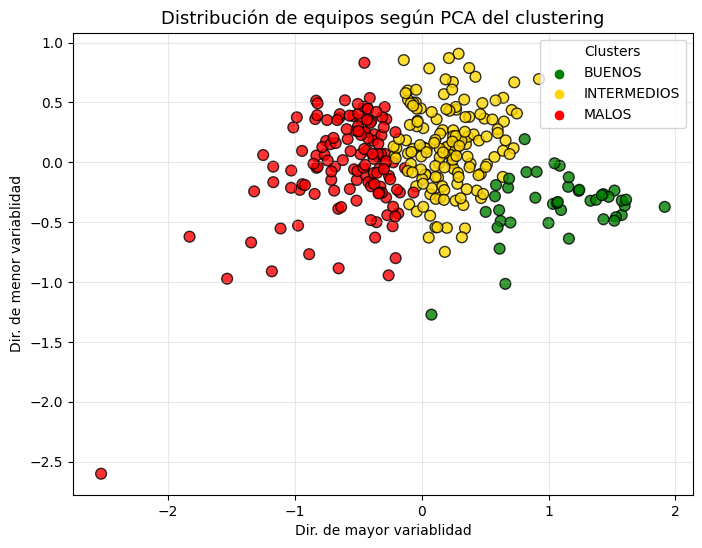

In [27]:
# 1️⃣ Reducimos a 2 componentes principales
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 2️⃣ Asociamos colores personalizados según el label
color_map = {
    'BUENOS': 'green',
    'INTERMEDIOS': 'gold',
    'MALOS': 'red'
}
colors = df_model['performance_label'].map(color_map)

# 3️⃣ Gráfico PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], 
            c=colors, 
            s=60, 
            edgecolor='k', 
            alpha=0.8)

# Etiquetas y título
plt.title("Distribución de equipos según PCA del clustering", fontsize=13)
plt.xlabel("Dir. de mayor variablidad")
plt.ylabel("Dir. de menor variablidad")

# Leyenda
for label, color in color_map.items():
    plt.scatter([], [], c=color, label=label)
plt.legend(title="Clusters", loc='best')

plt.grid(alpha=0.3)
plt.show()

Dir. de mayor variablidad indica: la combinación de variables (ofensivo, defensivo, táctico) que más explica las diferencias entre equipos.
Dir. de menor variablidad indica: la combinacion de variables con un grado menor de insidencia (estilo de juego o equilibrio)

VALIDACION CONTEXTUAL

In [28]:
# Seleccionamos muestras balanceadas de cada grupo
sample_buenos = df_model[df_model['performance_label'] == 'BUENOS'].sample(5, random_state=1)
sample_intermedios = df_model[df_model['performance_label'] == 'INTERMEDIOS'].sample(5, random_state=1)
sample_malos = df_model[df_model['performance_label'] == 'MALOS'].sample(5, random_state=1)

# Unimos todo en una sola tabla
df_context = pd.concat([sample_buenos, sample_intermedios, sample_malos])

# Columnas clave para revisar
cols_show = [
    'team', 'season_id',
    'offensive_score', 'defensive_score', 'tactical_score', 'performance_score',
    'performance_label'
]

# Mostramos tabla ordenada por tipo
display(df_context[cols_show].sort_values('performance_label'))


,team,season_id,offensive_score,defensive_score,tactical_score,performance_score,performance_label
34,Real Madrid,2,0.439004,0.434666,0.750934,0.484059,BUENOS
22,Barcelona,2,0.616186,0.474186,0.642388,0.563316,BUENOS
194,Real Madrid,27,0.626288,0.465956,0.617452,0.560830,BUENOS
305,Barcelona,90,0.509761,0.476014,0.709081,0.526160,BUENOS
158,Valencia,25,0.506300,0.405902,0.462520,0.459574,BUENOS
227,Celta Vigo,39,0.400534,0.370881,0.561966,0.412888,INTERMEDIOS
276,Real Madrid,41,0.252567,0.416989,0.461150,0.349623,INTERMEDIOS
111,Rayo Vallecano,23,0.133759,0.504337,0.316970,0.309472,INTERMEDIOS
232,Mallorca,39,0.184087,0.481809,0.359309,0.329459,INTERMEDIOS
222,Sevilla,38,0.306614,0.493385,0.480621,0.407423,INTERMEDIOS


CREACION DE PALO GOL FC

In [29]:
# 1) Features que usamos para clusterizar
features = ['offensive_score', 'defensive_score', 'tactical_score', 'performance_score']

# 2) Definimos un equipo ficticio con perfil MUY OFENSIVO
#    (podés tocar estos tres primeros valores si querés probar otros perfiles)
palo_off = 0.18   # alto en ofensivo
palo_def = 0.37   # medio en defensivo
palo_tac = 0.39   # medio/alto en táctico

# Mismo cálculo de performance_score que usamos en tu pipeline
palo_perf = 0.45*palo_off + 0.40*palo_def + 0.15*palo_tac

palo_row = pd.DataFrame([{
    'team': 'Palo Gol FC',
    'season_id': int(df_model['season_id'].max()) + 1,  # nueva temporada simbólica
    'offensive_score': palo_off,
    'defensive_score': palo_def,
    'tactical_score' : palo_tac,
    'performance_score': palo_perf
}])

# 3) Entrenamos scaler + KMeans SOLO con los equipos reales (sin Palo)
base = df_model[['team','season_id'] + features].dropna().copy()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(base[features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X_scaled)
base['cluster'] = clusters

# 4) Orden semántico de clusters por performance (para BUENOS/INTERMEDIOS/MALOS)
cluster_means = base.groupby('cluster')['performance_score'].mean().sort_values(ascending=False)
cluster_order = cluster_means.index.tolist()

label_map = {}
for i, cl in enumerate(cluster_order):
    label_map[cl] = ['BUENOS', 'INTERMEDIOS', 'MALOS'][i]  # 0→BUENOS, 1→INTERMEDIOS, 2→MALOS según ranking

base['performance_label'] = base['cluster'].map(label_map)

# 5) Transformamos y predecimos para Palo Gol FC
Xp = scaler.transform(palo_row[features])
palo_cluster = kmeans.predict(Xp)[0]
palo_label = label_map[palo_cluster]

# 6) Equipos más cercanos a Palo (en espacio escalado) para dar contexto
#    (distancia euclídea a Palo en X_scaled)
from numpy.linalg import norm

palo_vec = Xp[0]
dists = norm(X_scaled - palo_vec, axis=1)
base['dist_to_palo'] = dists
closest = (base
           .sort_values('dist_to_palo')
           .loc[:, ['team','season_id','performance_label','dist_to_palo'] + features]
           .head(5))

# 7) Output
print("🏟️  Simulación de cluster para 'Palo Gol FC'")
print(f"   Scores → Off: {palo_off:.2f} | Def: {palo_def:.2f} | Tac: {palo_tac:.2f} | Perf: {palo_perf:.3f}")
print(f"   ➜ Quedaría en el cluster: **{palo_label}**")

print("\n👥 Equipos más cercanos a 'Palo Gol FC' (en el espacio de clustering):")
display(closest.reset_index(drop=True))

# (Opcional) Mostrar también la fila de Palo para guardar referencia
display(palo_row)


🏟️  Simulación de cluster para 'Palo Gol FC'
   Scores → Off: 0.18 | Def: 0.37 | Tac: 0.39 | Perf: 0.287
   ➜ Quedaría en el cluster: **MALOS**

👥 Equipos más cercanos a 'Palo Gol FC' (en el espacio de clustering):


,team,season_id,performance_label,dist_to_palo,offensive_score,defensive_score,tactical_score,performance_score
0,Atlético Madrid,22,MALOS,0.131505,0.197377,0.368916,0.380996,0.293535
1,Racing Santander,21,MALOS,0.183461,0.154014,0.369742,0.393997,0.276303
2,Sporting Gijón,41,MALOS,0.184302,0.189808,0.367403,0.411405,0.294085
3,Leganés,42,MALOS,0.329120,0.182764,0.376728,0.430228,0.297469
4,Sevilla,22,MALOS,0.364960,0.193016,0.357514,0.431673,0.294614


,team,season_id,offensive_score,defensive_score,tactical_score,performance_score
0,Palo Gol FC,91,0.18,0.37,0.39,0.2875


5.2 Clasificación

Primero definimos la variable error de estudio RMSE y separamos los datos de entrenamiento y validacion (QUE SE VA A USAR EN CLASIFICACION Y PREDICCION)

In [30]:
# RMSE (función definida en la celda 39)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Features y target (la misma división de tu Regresión Lineal 5.3.2)
features = ['offensive_score', 'defensive_score', 'tactical_score']
target   = 'performance_score' # Usamos 'performance_score' para el split inicial de X

# Split temporal (últimas 2 temporadas para validación)
last_n_seasons = 2
seasons_sorted = np.sort(df_model['season_id'].unique())
test_seasons   = seasons_sorted[-last_n_seasons:]
train_seasons  = seasons_sorted[:-last_n_seasons]

train_df = df_model[df_model['season_id'].isin(train_seasons)].copy()
valid_df = df_model[df_model['season_id'].isin(test_seasons)].copy()

X_train = train_df[features].values
X_valid = valid_df[features].values

# 📌 Target Categórico (la etiqueta a predecir en clasificación)
y_train_cat = train_df['performance_label'].values
y_valid_cat = valid_df['performance_label'].values

print("✅ Datos de entrenamiento y validación listos.")

✅ Datos de entrenamiento y validación listos.


Grafico de barras: X (Season_year). Violeta / Y (Cantidad de datos). Verde

C:\Users\Tomas\AppData\Local\Temp\ipykernel_27392\303874824.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_counts.index, y=season_counts.values, palette=colors)


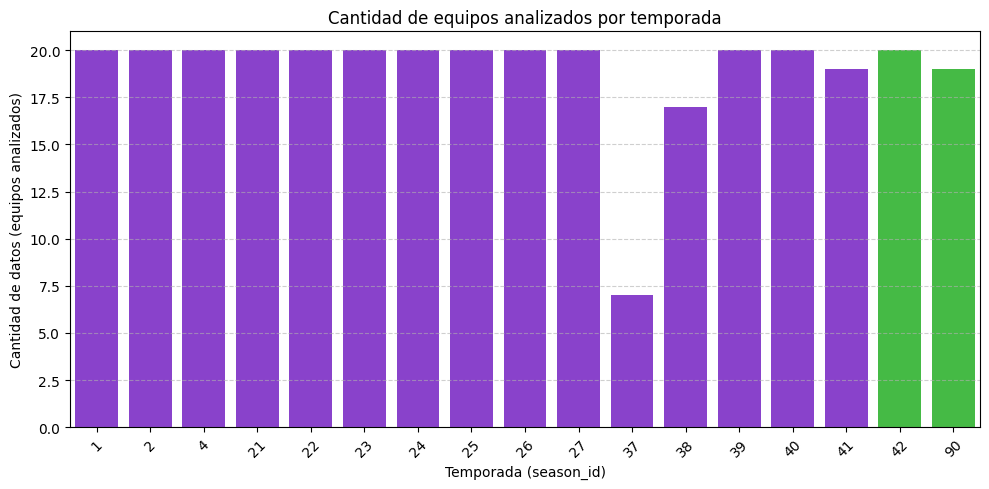

In [31]:
# Conteo por temporada
season_counts = df_model['season_id'].value_counts().sort_index()

# Temporadas de validación: 42 y 90
test_seasons = {42, 90}

# Violeta para train, verde para test (42 y 90)
colors = ['#32CD32' if int(s) in test_seasons else '#8A2BE2' for s in season_counts.index]

plt.figure(figsize=(10,5))
sns.barplot(x=season_counts.index, y=season_counts.values, palette=colors)
plt.title("Cantidad de equipos analizados por temporada")
plt.xlabel("Temporada (season_id)")
plt.ylabel("Cantidad de datos (equipos analizados)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

EJE Y = Cantidad de equipos analizados en esa temporada

In [32]:
# ---------------------------------------
# BLOQUE PREVIO - Preparación común para RF y SVM
# ---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Variables predictoras (características)
features = ['offensive_score', 'defensive_score', 'tactical_score', 'performance_score']

# Variable objetivo categórica
target = 'performance_label'

# Eliminar filas con datos faltantes
df_clean = df_model[features + [target]].dropna().copy()

# Codificar etiquetas categóricas (BUENOS / INTERMEDIOS / MALOS)
le = LabelEncoder()
df_clean['target_encoded'] = le.fit_transform(df_clean[target])

# División estratificada para asegurar proporciones equilibradas por clase
X = df_clean[features].values
y = df_clean['target_encoded'].values

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"✅ Split completado — Train: {X_train.shape[0]}, Valid: {X_valid.shape[0]}")
print(f"Clases codificadas: {list(le.classes_)}")


✅ Split completado — Train: 225, Valid: 97
Clases codificadas: ['BUENOS', 'INTERMEDIOS', 'MALOS']


5.2.1 Random forest. Para ver qué métricas (ofensiva, defensiva o táctica) pesan más para determinar el rendimiento global del equipo.

✅ Random Forest — Resultados de la Clasificación:
   Accuracy (Precisión): 0.9278

Reporte de Clasificación:
              precision    recall  f1-score   support

      BUENOS       1.00      0.92      0.96        13
 INTERMEDIOS       0.88      0.98      0.92        44
       MALOS       0.97      0.88      0.92        40

    accuracy                           0.93        97
   macro avg       0.95      0.93      0.94        97
weighted avg       0.93      0.93      0.93        97



,feature,importance
3,performance_score,0.489309
0,offensive_score,0.279561
1,defensive_score,0.139470
2,tactical_score,0.091659


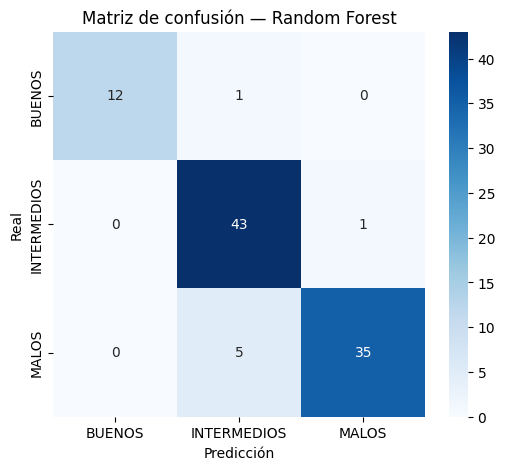

In [33]:
# ---------------------------------------
# RANDOM FOREST - Clasificación
# ---------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Pipeline de Clasificación
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

# Entrenamiento
rf_pipe.fit(X_train, y_train)

# Predicción
y_pred_rf = rf_pipe.predict(X_valid)

# Evaluación
acc_rf = accuracy_score(y_valid, y_pred_rf)
print("✅ Random Forest — Resultados de la Clasificación:")
print(f"   Accuracy (Precisión): {acc_rf:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_valid, y_pred_rf, target_names=le.classes_))

# Importancia de variables
importances = rf_pipe.named_steps['rf'].feature_importances_
importance_df = pd.DataFrame({'feature': features, 'importance': importances}).sort_values('importance', ascending=False)
display(importance_df)

# Matriz de confusión
cm_rf = confusion_matrix(y_valid, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de confusión — Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


Explicacion resultados:
*Precision del Random Forest=0.89% => Quiere decir que clasifico bien a un 90% de los equipos de las temporadas de validacion
*Wheighted avg => Promedio de 90% de calidad de modelo en base al promedio de
*BUENOS/INTERMEDIOS/MALOS => Los valores de tabla muestra la exactitud con la que clasifico

C:\Users\Tomas\AppData\Local\Temp\ipykernel_27392\2659527054.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


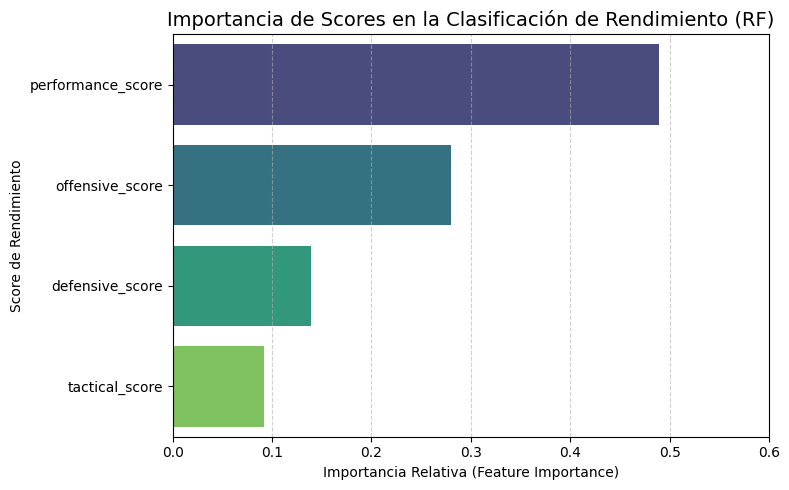

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x='importance', 
    y='feature', 
    data=importance_df,
    palette='viridis' # Un esquema de color atractivo
)

plt.title('Importancia de Scores en la Clasificación de Rendimiento (RF)', fontsize=14)
plt.xlabel('Importancia Relativa (Feature Importance)')
plt.ylabel('Score de Rendimiento')
plt.xlim(0, 0.6) # Ajustamos el límite X para que el 0.50 destaque
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

5.2.2. SVM (MAQUINA VIRTUAL ). Para comprobar lo mismo que con Random Forest y ver que modelo tiene mas precision. Esto se validara en base a la precision de clasificacion (Accuracy)

✅ SVM (RBF) — Accuracy test: 0.959
Mejor set de hiperparámetros: {'svc__C': 10, 'svc__gamma': 0.1}

Reporte de Clasificación:
              precision    recall  f1-score   support

      BUENOS       0.87      1.00      0.93        13
 INTERMEDIOS       0.98      0.95      0.97        44
       MALOS       0.97      0.95      0.96        40

    accuracy                           0.96        97
   macro avg       0.94      0.97      0.95        97
weighted avg       0.96      0.96      0.96        97



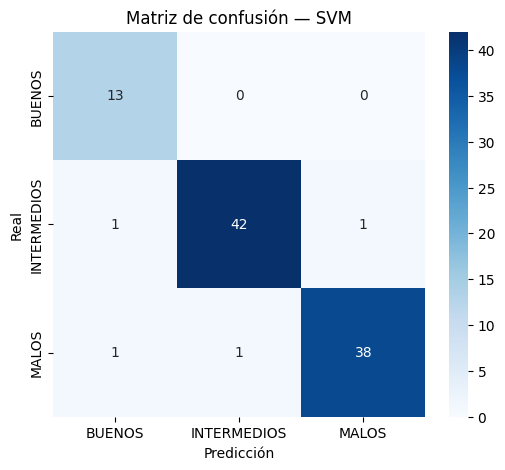

In [35]:
# ---------------------------------------
# SVM - Clasificación
# ---------------------------------------
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Pipeline + búsqueda de hiperparámetros
svm_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('svc', SVC(kernel='rbf', class_weight='balanced'))
])

param_grid = {
    'svc__C': [0.1, 1, 10, 50],
    'svc__gamma': ['scale', 0.1, 0.01, 0.001]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(svm_pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

svm_best = grid.best_estimator_
y_pred_svm = svm_best.predict(X_valid)

acc_svm = accuracy_score(y_valid, y_pred_svm)
print(f"✅ SVM (RBF) — Accuracy test: {acc_svm:.3f}")
print(f"Mejor set de hiperparámetros: {grid.best_params_}\n")
print("Reporte de Clasificación:")
print(classification_report(y_valid, y_pred_svm, target_names=le.classes_))

# Matriz de confusión
cm_svm = confusion_matrix(y_valid, y_pred_svm)
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de confusión — SVM')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


5.2.3 Comparacion entre Random Forest y SVM:

SVM obtuvo mayor precision (95% ante 89%).

Que significa lo que dice la matriz de confusion: La diagonal principal son los equipos que clasifico correectamente; fuera de esta daigonal son malas clasificaicones. Por ejemplo: definio un equipo MALO como BUENO

5.3 Predicciones. Para ello planteamos predicciones basadas en las primeras 15 temporadas como entrenamiento y las ultimas 2 de las 17 para validacion.

la definicion de datos de entrenamiento y validacion esta hecha posterior al punto 5.2 al definir en la misma celda el RMSE.

5.3.1 Regresion lineal - Prediccion continua con la variable 'performance_score' como objetivo

Pregunta a resolver:
“¿Cuál será el rendimiento esperado (performance_score) de cada equipo la próxima temporada?”

In [36]:
# Preparación ajustada

df_future = df_model.copy()

# Aseguramos orden temporal por equipo y temporada
df_future = df_future.sort_values(['team', 'season_id']).reset_index(drop=True)

# Crear la variable objetivo: performance_score de la próxima temporada
df_future['next_performance_score'] = (
    df_future.groupby('team')['performance_score'].shift(-1)
)

# --- FILTRO 1: equipos con al menos 5 temporadas registradas ---
team_counts = df_future['team'].value_counts()
valid_teams = team_counts[team_counts >= 5].index
df_future = df_future[df_future['team'].isin(valid_teams)]

# --- FILTRO 2: equipos presentes en las últimas 2 temporadas ---
last_two = sorted(df_future['season_id'].unique())[-2:]
teams_in_last_two = (
    df_future[df_future['season_id'].isin(last_two)]['team'].unique()
)
df_future = df_future[df_future['team'].isin(teams_in_last_two)]

# --- Eliminamos filas sin objetivo (sin próxima temporada conocida) ---
df_future = df_future.dropna(subset=['next_performance_score']).reset_index(drop=True)

# --- Diagnóstico ---
print(f"✅ Dataset listo para predicción temporal refinada: {df_future.shape[0]} registros")
print(f"   Equipos incluidos: {df_future['team'].nunique()} con ≥5 temporadas y activos recientes.")
print(f"   Última temporada seleccionada para análisis contextual: 90\n")

display(
    df_future[['team','season_id','performance_score','next_performance_score']]
    .sort_values(['team','season_id'])
    .head(10)
)



✅ Dataset listo para predicción temporal refinada: 222 registros
   Equipos incluidos: 19 con ≥5 temporadas y activos recientes.
   Última temporada seleccionada para análisis contextual: 90



,team,season_id,performance_score,next_performance_score
0,Athletic Club,1,0.353745,0.291335
1,Athletic Club,2,0.291335,0.302108
2,Athletic Club,4,0.302108,0.373535
3,Athletic Club,21,0.373535,0.359336
4,Athletic Club,22,0.359336,0.294566
5,Athletic Club,23,0.294566,0.431386
6,Athletic Club,24,0.431386,0.416714
7,Athletic Club,25,0.416714,0.373659
8,Athletic Club,26,0.373659,0.432095
9,Athletic Club,27,0.432095,0.307998


In [37]:

# División temporal entrenamiento / validación

# Definimos variables predictoras (features) y target (rendimiento futuro)
features = ['offensive_score', 'defensive_score', 'tactical_score', 'performance_score']
target = 'next_performance_score'

# Determinamos el corte temporal: las últimas 2 temporadas para validación
last_seasons = sorted(df_future['season_id'].unique())[-2:]
train_df = df_future[~df_future['season_id'].isin(last_seasons)]
valid_df = df_future[df_future['season_id'].isin(last_seasons)]

X_train, y_train = train_df[features], train_df[target]
X_valid, y_valid = valid_df[features], valid_df[target]

print(f"Entrenamiento: {train_df['season_id'].nunique()} temporadas, {X_train.shape[0]} muestras")
print(f"Validación: {valid_df['season_id'].nunique()} temporadas, {X_valid.shape[0]} muestras")


Entrenamiento: 14 temporadas, 194 muestras
Validación: 2 temporadas, 28 muestras


Prediccion Global

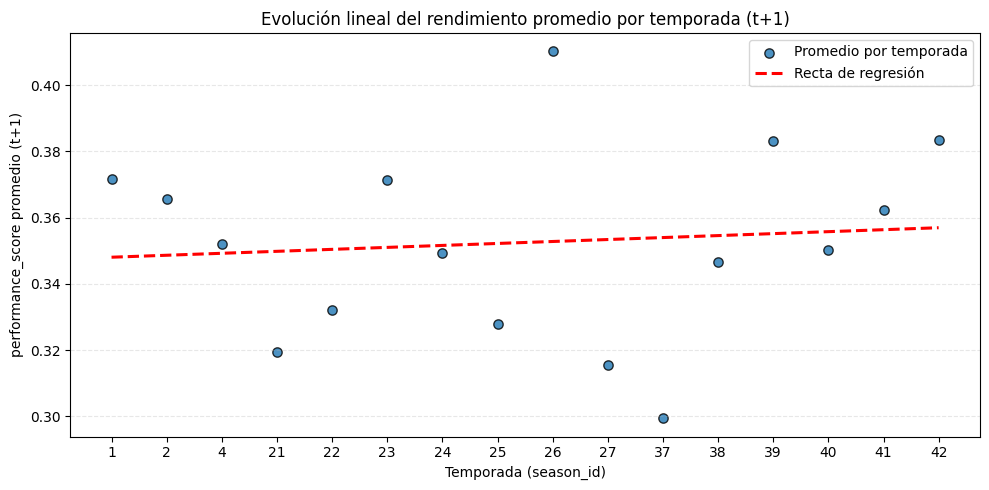

R²: 0.0095 | RMSE: 0.0279


In [55]:
# === Evolución temporal (temporadas equidistantes) + R² y RMSE ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 0) Asegurar dataset con variable objetivo
if 'next_performance_score' not in df_model.columns:
    df_future = df_model.sort_values(['team','season_id']).copy()
    df_future['next_performance_score'] = (
        df_future.groupby('team')['performance_score'].shift(-1)
    )
    df_future = df_future.dropna(subset=['next_performance_score']).copy()
else:
    df_future = df_model.dropna(subset=['next_performance_score']).copy()

# 1) Lista completa de temporadas y promedio global
seasons_all = sorted(df_future['season_id'].unique().tolist())
season_avg = (
    df_future.groupby('season_id')['next_performance_score']
    .mean()
    .reindex(seasons_all)
)

# 2) Convertir a eje equidistante (ordinal)
mask_valid = season_avg.notna()
X_idx = np.arange(len(season_avg))[mask_valid].reshape(-1, 1)
y_fit = season_avg[mask_valid].values

# 3) Ajuste lineal
lin = LinearRegression().fit(X_idx, y_fit)
y_pred = lin.predict(X_idx)

r2 = r2_score(y_fit, y_pred)
rmse = np.sqrt(mean_squared_error(y_fit, y_pred))
slope = lin.coef_[0]
intercept = lin.intercept_

# 4) Línea suavizada para la recta de regresión
x_line = np.linspace(0, len(season_avg)-1, 200).reshape(-1, 1)
y_line = lin.predict(x_line)

# 5) Gráfico
plt.figure(figsize=(10, 5))
plt.scatter(range(len(seasons_all)), season_avg, s=45, edgecolor='k',
            alpha=0.8, label='Promedio por temporada')
plt.plot(x_line, y_line, 'r--', linewidth=2.2, label='Recta de regresión')

plt.xticks(range(len(seasons_all)), seasons_all, rotation=0)
plt.xlabel("Temporada (season_id)")
plt.ylabel("performance_score promedio (t+1)")
plt.title("Evolución lineal del rendimiento promedio por temporada (t+1)")
plt.legend()
plt.grid(axis='y', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"R²: {r2:.4f} | RMSE: {rmse:.4f}")


Explicacion
*El modelo logra cierta capacidad de anticipar rendimiento futuro, pero el fútbol tiene alta variabilidad, por lo que un R² bajo es esperable. Por lo tanto es mejor que un modelo al azar pero no logra una prediccion 100% buena

5.3.2 Gradient Boosting Regressor. Tambien para comparar con la prediccion realizada mediante Regresion lineal. Comparacion de precision basada en las funciones de costo (rmse y r2) 

In [57]:
# 1) Asegurar dataset temporal con 'next_performance_score'
if 'next_performance_score' not in df_model.columns:
    df_future = df_model.sort_values(['team','season_id']).copy()
    df_future['next_performance_score'] = (
        df_future.groupby('team')['performance_score'].shift(-1)
    )
    df_future = df_future.dropna(subset=['next_performance_score']).copy()
else:
    df_future = df_model.dropna(subset=['next_performance_score']).copy()

# 2) Split temporal: entreno con todas menos las 2 últimas temporadas, test = últimas 2
features_reg = ['offensive_score', 'defensive_score', 'tactical_score']
seasons_sorted = np.sort(df_future['season_id'].unique())
train_seasons = seasons_sorted[:-2]
test_seasons  = seasons_sorted[-2:]

X_train = df_future[df_future['season_id'].isin(train_seasons)][features_reg].values
y_train = df_future[df_future['season_id'].isin(train_seasons)]['next_performance_score'].values
X_test  = df_future[df_future['season_id'].isin(test_seasons)][features_reg].values
y_test  = df_future[df_future['season_id'].isin(test_seasons)]['next_performance_score'].values

# 3) Baseline: Regresión lineal (para comparar)
lr_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('lr', LinearRegression())
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)   # sin 'squared'
rmse_lr = np.sqrt(mse_lr)

# 4) Modelo: Gradient Boosting
gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    random_state=42
)

gbr_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('gbr', gbr)
])

gbr_pipe.fit(X_train, y_train)
y_pred_gbr = gbr_pipe.predict(X_test)
r2_gbr = r2_score(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)

print("✅ Predicción de rendimiento (próxima temporada)")
print(f"Linear Regression — R²: {r2_lr:.3f} | RMSE: {rmse_lr:.3f}")
print(f"Gradient Boosting — R²: {r2_gbr:.3f} | RMSE: {rmse_gbr:.3f}")

mejor = "Gradient Boosting" if r2_gbr > r2_lr else "Regresión lineal"
print(f"\n🏁 Mejor por R² en tu split temporal: {mejor}")

✅ Predicción de rendimiento (próxima temporada)
Linear Regression — R²: 0.283 | RMSE: 0.056
Gradient Boosting — R²: -0.064 | RMSE: 0.069

🏁 Mejor por R² en tu split temporal: Regresión lineal


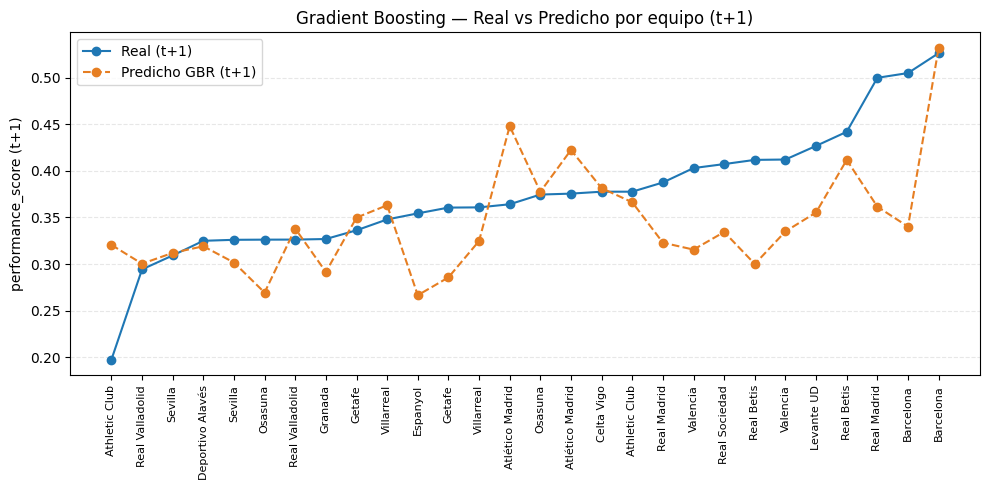

In [ ]:
# === Gráfico de comparación Real vs Predicho (t+1) — Modelo Gradient Boosting ===

# Ordenar por valor real para una lectura más clara
results_gbr = df_gbr.sort_values('real_next_score').reset_index(drop=True)
x = np.arange(len(results_gbr))

plt.figure(figsize=(10, 5))
plt.plot(x, results_gbr['real_next_score'], 'o-', label='Real (t+1)', color='#1f77b4')
plt.plot(x, results_gbr['predicted_next_score'], 'o--', label='Predicho GBR (t+1)', color='#e67e22')
plt.xticks(x, results_gbr['team'], rotation=90, fontsize=8)
plt.ylabel("performance_score (t+1)")
plt.title("Gradient Boosting — Real vs Predicho por equipo (t+1)")
plt.legend()
plt.grid(axis='y', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()


6.1 Eleccion de estudios realizados

CLASIFICACION: SE ESCOGIO EL SVM DEBIDO A QUE OBTUVO UN MEJOR PORCENTAJE DE PRECISION

PREDICCION: SE ESCOGIO REGRESION LINEAL QUE OBTUVE UN MEJOR RESULTADO r2 Y UN rmse MENOR QUE EL GRADIENT BOOSTING

6.2 Validacion cruzada

6.2.1 Validacion cruzada de la clasificacion: SVM

In [49]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Definir validación cruzada estratificada (para clasificación)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Mejor modelo obtenido (puede ser el 'svm_best' ya entrenado)
svm_final = svm_best  # usa el mejor estimador del GridSearch

# Calcular accuracy promedio en validación cruzada
cv_scores = cross_val_score(svm_final, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print("✅ Validación Cruzada — SVM (Clasificación)")
print(f"Accuracy promedio: {cv_scores.mean():.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")
print(f"Puntajes individuales por fold: {np.round(cv_scores, 4)}")

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

6.2.2 Validacion cruzada de la prediccion: Regresion Lineal

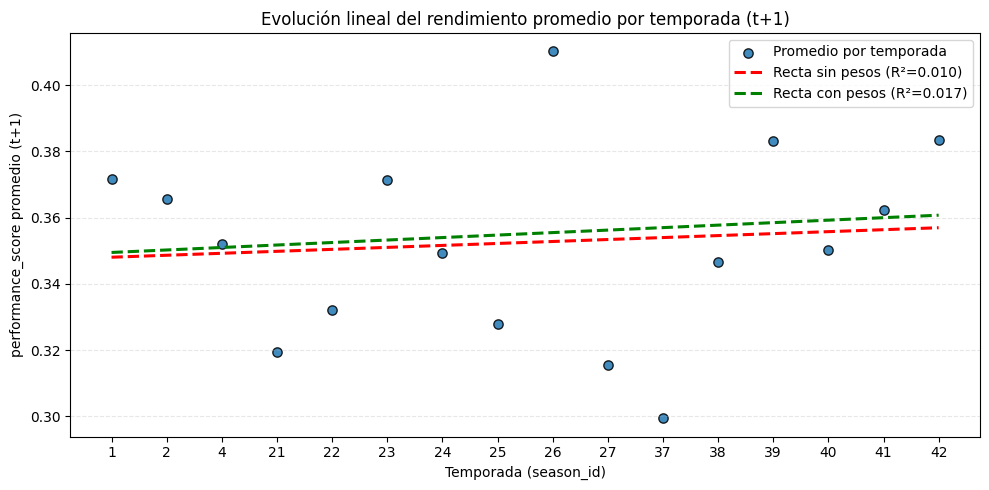

⟂ Sin pesos -> R²: 0.0095 | RMSE: 0.0279
⟂ Con pesos -> R²: 0.0169 | RMSE: 0.0262  (pesos = #equipos por temporada)


In [61]:
# === Ajuste lineal global sobre temporadas equidistantes (con y sin pesos) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# --- 0) Dataset con objetivo (igual que tu celda) ---
if 'next_performance_score' not in df_model.columns:
    df_future = df_model.sort_values(['team','season_id']).copy()
    df_future['next_performance_score'] = (
        df_future.groupby('team')['performance_score'].shift(-1)
    )
    df_future = df_future.dropna(subset=['next_performance_score']).copy()
else:
    df_future = df_model.dropna(subset=['next_performance_score']).copy()

# --- 1) Promedio por temporada & conteo por temporada (para pesos opcionales) ---
seasons_all = sorted(df_future['season_id'].unique().tolist())
season_avg = (
    df_future.groupby('season_id')['next_performance_score']
    .mean()
    .reindex(seasons_all)
)
season_cnt = (
    df_future.groupby('season_id')['next_performance_score']
    .size()
    .reindex(seasons_all)
)

# --- 2) Eje equidistante y máscara válida ---
mask_valid = season_avg.notna()
X_idx = np.arange(len(season_avg))[mask_valid].reshape(-1, 1)
y_fit = season_avg[mask_valid].values
w_fit = season_cnt[mask_valid].values  # pesos = #equipos por temporada (opcional)

# --- 3) Ajuste SIN pesos ---
lin = LinearRegression().fit(X_idx, y_fit)
y_pred = lin.predict(X_idx)
r2 = r2_score(y_fit, y_pred)
rmse = np.sqrt(mean_squared_error(y_fit, y_pred))

# --- 4) Ajuste CON pesos (opcional) ---
lin_w = LinearRegression().fit(X_idx, y_fit, sample_weight=w_fit)
y_pred_w = lin_w.predict(X_idx)
r2_w = r2_score(y_fit, y_pred_w, sample_weight=w_fit)
rmse_w = np.sqrt(mean_squared_error(y_fit, y_pred_w, sample_weight=w_fit))

# --- 5) Recta para graficar (eje equidistante) ---
x_line = np.linspace(0, len(season_avg)-1, 200).reshape(-1, 1)
y_line = lin.predict(x_line)
y_line_w = lin_w.predict(x_line)

# --- 6) Gráfico (puntos por temporada y dos rectas) ---
plt.figure(figsize=(10, 5))
plt.scatter(np.arange(len(seasons_all)), season_avg, s=45, edgecolor='k',
            alpha=0.85, label='Promedio por temporada')
plt.plot(x_line, y_line, 'r--', linewidth=2.2, label=f'Recta sin pesos (R²={r2:.3f})')
plt.plot(x_line, y_line_w, 'g--', linewidth=2.2, label=f'Recta con pesos (R²={r2_w:.3f})')

plt.xticks(range(len(seasons_all)), seasons_all, rotation=0)
plt.xlabel("Temporada (season_id)")
plt.ylabel("performance_score promedio (t+1)")
plt.title("Evolución lineal del rendimiento promedio por temporada (t+1)")
plt.legend()
plt.grid(axis='y', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"⟂ Sin pesos -> R²: {r2:.4f} | RMSE: {rmse:.4f}")
print(f"⟂ Con pesos -> R²: {r2_w:.4f} | RMSE: {rmse_w:.4f}  (pesos = #equipos por temporada)")


In [62]:
# === Validación cruzada temporal (TimeSeriesSplit) para la tendencia por temporada ===
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
import numpy as np

# Reutilizamos X_idx, y_fit definidos arriba (ya sin NaNs)
# (Si querés usar pesos en CV, habría que implementar un loop manual; aquí lo hacemos simple.)

pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('lr', LinearRegression())
])

# Con ~15–18 temporadas, usar 4–5 splits suele ir bien. Ajustá si te falta data.
n_splits = min(5, max(2, len(X_idx) - 3))  # asegura suficientes puntos por fold
tscv = TimeSeriesSplit(n_splits=n_splits)

r2_scores = cross_val_score(pipe, X_idx, y_fit, cv=tscv, scoring='r2')
rmse_scores = -cross_val_score(pipe, X_idx, y_fit, cv=tscv,
                               scoring='neg_root_mean_squared_error')

print("✅ Validación cruzada temporal — Regresión lineal (por temporada)")
print(f"Splits: {n_splits}")
print(f"R² (CV):   {r2_scores.mean():.4f}")
print(f"RMSE (CV): {rmse_scores.mean():.4f}")
print(f"R² por fold:   {np.round(r2_scores, 4)}")
print(f"RMSE por fold: {np.round(rmse_scores, 4)}")


✅ Validación cruzada temporal — Regresión lineal (por temporada)
Splits: 5
R² (CV):   -2.5957
RMSE (CV): 0.0336
R² por fold:   [ 0.2938 -0.4067 -0.9078 -4.9591 -6.9989]
RMSE por fold: [0.009  0.0562 0.0325 0.0401 0.03  ]
